# VSE Simulation — standalone notebook

This notebook reproduces the **Voter Satisfaction Efficiency (VSE)** simulation methodology
originally developed in the [`vse-sim`](https://github.com/electionscience/vse-sim) project for
five voting systems: **Plurality, Approval, RCV/IRV, STAR, and Condorcet (Schulze)**.

**This notebook is fully standalone** — it has no dependency on the `vse-sim` repository or
package being installed or present. The "Vendored library" section below is a verbatim copy of
exactly the code these 5 methods need (electorate models, ballot logic, the VSE formula itself),
reproduced directly in this notebook's own cells. Only `numpy`, `scipy`, and `matplotlib` need to
be installed — this notebook can be shared, run on Colab, or embedded standalone anywhere.

It does **not** reimplement the methodology — every honest ballot, every strategic ballot, and
the VSE formula are the same code that produced the published numbers in this project's
[`docs/VSEbasic.md`](https://github.com/electionscience/vse-sim/blob/main/docs/VSEbasic.md) and
[`docs/irv-simulation.md`](https://github.com/electionscience/vse-sim/blob/main/docs/irv-simulation.md)
(see the note in Section 7 below about one known discrepancy between that table and the current
code).

**New in this version:** epistemic noise — voters cast ballots on a *perceived* utility that's a
noisy version of their true utility, modeling the idea that voters may be uncertain about their
own preferences or misinformed about candidates. See the "Epistemic noise" sections below.

**Not included (deferred to a future checkpoint):** participation friction / ballot fatigue
(forced ballot truncation), and top-2/top-3 hybrid methods (e.g. Approval Top 2, "Approval Top 3
→ Schulze"). Section 12 ("Next steps") describes where these would hook in.

**Also dropped:** Ranked Pairs (a second Condorcet completion method) — Schulze alone represents
Condorcet going forward.


## How this notebook is organized

1. **Vendored library** — self-contained copy of the electorate models, ballot logic, and VSE
   formula (sections below, mirroring the original project's module layout).
2. **Epistemic noise** — voters perceive a noisy version of their true utilities.
3. **Top-2 hybrid methods** — Plurality Top 2 and Approval Top 2.
4. **Participation friction** — unfamiliarity and ballot fatigue.
5. **Parameters** — the knobs you'll actually want to change.
6. **Methods** — the 9 voting systems being compared.
7. **Simulation loop, Run, Results, Sanity check, Chart** — run the simulation and look at VSE.
8. **Epistemic noise demo & range table** — VSE vs. voter information.
9. **Reusable comparison tooling, then Approval's flavors vs. STAR/Schulze** — a sweep/table/chart
   helper you can point at any methods and any one parameter, used to check whether STAR/Schulze's
   VSE edge over Approval (and its Top-2 variants) holds up under noise and both friction
   mechanisms, then a joint "realistic conditions" scenario comparison — noise, unfamiliarity, and
   fatigue all degraded *together* rather than one at a time — quantifying how much of STAR's edge
   survives once none of its ideal-information assumptions hold.
10. **Next steps** — what's deliberately not built yet, and where it would hook in.


## 1. Vendored library

The classes and functions below are copied, with one small and clearly-marked addition, from the
`vse_sim` Python package at [electionscience/vse-sim](https://github.com/electionscience/vse-sim)
(the repository this notebook was originally developed alongside), so this notebook has zero
dependency on that repository being present. Internal `from .xxx import yyy` lines between the
original package's own modules are simply omitted here — everything lives in this one notebook's
namespace instead, in the same dependency order the original modules load in.

**Included:** the shared `Method` base class and VSE formula (`core.py`), the electorate/voter
models needed for the "kitchen sink" hierarchical-cluster model used for every published VSE
number (`voter_models.py`, trimmed to what `KSModel` needs), the strategic-voting and media-noise
machinery (`strategies.py`), and the 5 requested voting methods (`methods/*.py`).

**Not included:** anything only needed by voting methods this notebook doesn't use (Ranked
Pairs, Majority Judgment, Borda, 3-2-1, IRNR, ...), the CSV/batch-run harness (`CsvBatch`), and a
few electorate models unrelated to the one used here (`PolyaModel`, `QModel`, `ReverseModel`,
`DeterministicModel`).

**One deliberate modification:** `Method.resultsTable`/`vseOn` gain an optional `scoring_voters`
parameter (defaulting to the original behavior when omitted) — see Section 2, "Epistemic noise",
for why.


### 1.1 Setup: shared imports

In [1]:
import random
import math
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display


### 1.2 Utility decorators (from `decorators.py`)

In [2]:
from functools import update_wrapper, wraps
from inspect import getfullargspec, isfunction
from itertools import starmap


def decorator(d):
    """Make function d a decorator: d wraps a function fn."""
    def _d(fn):
        return update_wrapper(d(fn), fn)
    return _d
decorator = decorator(decorator)(decorator)


@decorator
def autoassign(*names, **kwargs):
    """
    autoassign(function) -> method
    autoassign(*argnames) -> decorator
    autoassign(exclude=argnames) -> decorator.

    Lets a method assign (some of) its arguments as attributes of ``self``
    automatically -- used throughout below instead of writing out
    ``self.x = x`` for every constructor argument.
    """
    if kwargs:
        exclude, f = set(kwargs['exclude']), None
        def sieve(values):
            return filter(lambda nv: nv[0] not in exclude, values)
    elif len(names) == 1 and isfunction(names[0]):
        f = names[0]
        def sieve(values):
            return values
    else:
        names, f = set(names), None
        def sieve(values):
            return [nv for nv in values if nv[0] in names]
    def decorator(f):
        spec = getfullargspec(f)
        fargnames, fdefaults = spec.args, spec.defaults
        fargnames, fdefaults = fargnames[1:], fdefaults or ()
        defaults = list(sieve(zip(reversed(fargnames), reversed(fdefaults), strict=False)))
        @wraps(f)
        def decorated(self, *args, **kwargs):
            assigned = dict(sieve(zip(fargnames, args, strict=False)))
            assigned.update(sieve(kwargs.items()))
            for _ in starmap(assigned.setdefault, defaults):
                pass
            self.__dict__.update(assigned)
            return f(self, *args, **kwargs)
        return decorated
    return f and decorator(f) or decorator


_missing = object()

@decorator
class cached_property(object):
    """Converts a function into a lazy property: computed once, then cached
    on the instance's own __dict__."""

    def __init__(self, func, name=None, doc=None):
        self.__name__ = name or func.__name__
        self.__module__ = func.__module__
        self.__doc__ = doc or func.__doc__
        self.func = func

    def __get__(self, obj, type=None):
        if obj is None:
            return self
        value = obj.__dict__.get(self.__name__, _missing)
        if value is _missing:
            value = self.func(obj)
            obj.__dict__[self.__name__] = value
        return value


### 1.3 Core: `Method` base class & VSE formula (from `core.py`)

`Method` is the shared base every voting method below subclasses. `normalized_vse` is the exact
formula behind every VSE number this notebook produces:
`vse = (util - rand) / (best - rand)`, where `best`/`rand` come from the electorate's true social
utilities (mean utility per candidate across all voters).

Two additions here (both marked inline): `resultsTable`/`vseOn` accept an optional
`scoring_voters` electorate. When ballots are cast on a *perceived* (possibly noisy) electorate
but VSE should still be scored against *true* utilities, pass the true electorate as
`scoring_voters` — see Section 2 below. They also stash that same true electorate as
`self._scoring_voters`, which the Top-2 hybrid methods in Section 3 read directly (their
"noiseless runoff" option needs true-utility access from inside `results()`, which doesn't
otherwise receive the electorate at all — see Section 3 for why).


In [3]:
from dataclasses import dataclass, field

from numpy import isclose, mean


def isnum(x):
    """Test whether an object is an instance of a built-in numeric type."""
    return next((1 for T in (int, float, complex) if isinstance(x, T)), 0)


class VseOneRun:
    @autoassign
    def __init__(self, result, tallyItems, strat):
        pass


class VseMethodRun:
    @autoassign
    def __init__(self, method, choosers, results):
        pass


@dataclass
class ElectionContext:
    """Mutable metadata scoped to one method instance and election."""
    extra_events: dict = field(default_factory=dict)


def normalized_vse(utility, best, random_baseline):
    """Normalize utility to VSE.

    When every candidate has the same social utility there is no possible
    improvement over random selection, so every method receives neutral VSE.
    """
    denominator = best - random_baseline
    if isclose(denominator, 0):
        return 0.0
    return (utility - random_baseline) / denominator


class SideTally(defaultdict):
    """Tracks how many voters are being strategic, etc.

    DO NOT use plain +; for this class it is equivalent to +=, but less readable.
    """
    def __init__(self):
        super().__init__(int)
        self._keys_initialized = False

    def initKeys(self, chooser):
        if self._keys_initialized:
            return
        try:
            self.keyList = chooser.allTallyKeys()
        except AttributeError:
            try:
                self.keyList = list(chooser)
            except TypeError:
                pass
        self._keys_initialized = True

    def serialize(self):
        try:
            return [self[key] for key in self.keyList]
        except AttributeError:
            return []

    def fullSerialize(self):
        try:
            return ([self[key] for key in self.keyList] +
                    [self[key] for key in self.keys() if key not in self.keyList])
        except AttributeError:
            return [self[key] for key in self.keys()]

    def itemList(self):
        try:
            kl = self.keyList
            return ([(k, self[k]) for k in kl] +
                    [(k, self[k]) for k in self.keys() if k not in kl])
        except AttributeError:
            return list(self.items())


class Tallies(list):
    """Used (ONCE) as an enumerator: gives an inexhaustible flow of SideTally
    objects. After that, use as a list to see those objects."""
    def __iter__(self):
        if hasattr(self, "used"):
            return super().__iter__()
        self.used = True
        return self

    def __next__(self):
        tally = SideTally()
        self.append(tally)
        return tally


class Method:
    """Base class for election methods. Holds some of the duct tape."""

    def __init__(self):
        self.context = ElectionContext()

    @property
    def extraEvents(self):
        """Compatibility view of metadata for this method's current election."""
        return self.context.extra_events

    @extraEvents.setter
    def extraEvents(self, value):
        self.context.extra_events = value

    def __str__(self):
        return self.__class__.__name__

    def results(self, ballots, **kwargs):
        """Combines ballots into results. Override for comparative methods."""
        if type(ballots) is not list:
            ballots = list(ballots)
        return list(map(self.candScore, zip(*ballots, strict=False)))

    @staticmethod  # cls is provided explicitly, not through binding
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        raise NotImplementedError(f"{cls} needs honBallot")

    @staticmethod
    def winner(results):
        """Find the winner once scores are already calculated. Override for
        ranked methods."""
        winScore = max(result for result in results if isnum(result))
        winners = [cand for (cand, score) in enumerate(results) if score == winScore]
        return random.choice(winners)

    def honBallotFor(self, voters):
        """This is where you'd do any setup necessary and create an honBallot
        function. The base version just returns honBallot."""
        return self.honBallot

    def dummyBallotFor(self, polls):
        return lambda cls, utilities, stratTally: utilities

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        """Create ballots and get results."""
        if tally is None:
            tally = SideTally()
        tally.initKeys(chooser)
        return dict(results=self.results([chooser(self.__class__, voter, tally)
                                  for voter in voters],
                              **kwargs),
                chooser=chooser.__name__,
                tally=tally)

    def multiResults(self, voters, chooserFuns=(), media=(lambda x, t: x),
                checkStrat=True):
        """Runs the honest election, then the strategic election (based on the
        honest results filtered through media), then one-sided-strategic,
        'smart' one-sided, and any caller-supplied chooserFuns."""
        honTally = SideTally()
        self.context = ElectionContext()
        hon = self.resultsFor(voters, self.honBallotFor(voters), honTally, isHonest=True)

        stratTally = SideTally()
        polls = media(hon["results"], stratTally)
        winner, _w, target, _t = self.stratTargetFor(sorted(enumerate(polls), key=lambda x: -x[1]))

        strat = self.resultsFor(voters, self.stratBallotFor(polls), stratTally)

        ossTally = SideTally()
        oss = self.resultsFor(voters, self.ballotChooserFor(OssChooser()), ossTally)
        ossWinner = oss["results"].index(max(oss["results"]))
        ossTally["worked"] += (1 if ossWinner == target else
                                    (0 if ossWinner == winner else -1))

        smart = dict(results=(hon["results"] if ossTally["worked"] == 1 else oss["results"]),
                chooser="smartOss",
                tally=SideTally())

        extraTallies = Tallies()
        results = ([strat, oss, smart] +
                [self.resultsFor(voters, self.ballotChooserFor(chooserFun), aTally)
                    for (chooserFun, aTally) in zip(chooserFuns, extraTallies, strict=False)]
                  )
        return ([(hon["results"], hon["chooser"], list(self.extraEvents.items()))] +
                [(r["results"], r["chooser"], r["tally"].itemList()) for r in results])

    def vseOn(self, voters, chooserFuns=(), scoring_voters=None, **args):
        """Finds honest and strategic VSE for this method on the given electorate.

        `scoring_voters` -- CHECKPOINT-2 ADDITION, not in the original: the
        electorate whose socUtils defines ground truth for VSE scoring.
        Defaults to `voters` (the original behavior) when not given -- pass a
        separate true electorate here when `voters` is a noisy *perceived*
        electorate (see make_perceived_electorate below), so ballots are cast
        on perception while VSE is still scored against ground truth.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's noiseless-runoff option.
        # Must be set BEFORE multiResults() runs -- results() (called from deep inside
        # multiResults, via resultsFor) reads self._scoring_voters for this same election;
        # setting it after multiResults() returns would leave results() reading the PREVIOUS
        # election's true electorate (or None, on the very first call).
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)

        vses = VseMethodRun(
            self.__class__,
            chooserFuns,
            [
                VseOneRun(
                    [normalized_vse(utils[self.winner(result)], best, rand)],
                    tally,
                    chooser,
                )
                for result, chooser, tally in multiResults
            ],
        )
        vses.extraEvents = dict(self.extraEvents)
        return vses

    def resultsTable(self, eid, emodel, cands, voters, chooserFuns=(), scoring_voters=None, **args):
        """As vseOn, but returns one CSV-row-shaped dict per chooser.
        See vseOn above for what `scoring_voters` (checkpoint-2 addition) does.
        """
        truth_voters = voters if scoring_voters is None else scoring_voters  # <-- checkpoint 2
        self._scoring_voters = truth_voters  # <-- checkpoint 3: exposed for Top2Base's noiseless-runoff option.
        # Must be set BEFORE multiResults() runs -- see the identical note in vseOn above.
        multiResults = self.multiResults(voters, chooserFuns, **args)
        utils = truth_voters.socUtils
        best = max(utils)
        rand = mean(utils)
        rows = []
        nvot = len(voters)
        for (result, chooser, tallyItems) in multiResults:
            winner = self.winner(result)
            utility = utils[winner]
            row = {
                "eid": eid,
                "emodel": emodel,
                "ncand": cands,
                "nvot": nvot,
                "best": best,
                "rand": rand,
                "method": str(self),
                "chooser": chooser,
                "winner": winner,  # checkpoint-4 addition: ground-truth Condorcet efficiency
                                   # needs to know which candidate a method actually elected.
                "util": utility,
                "vse": normalized_vse(utility, best, rand),
            }
            for (i, (k, v)) in enumerate(tallyItems):
                row[f"tallyName{str(i)}"] = str(k)
                row[f"tallyVal{str(i)}"] = str(v)
            rows.append(row)
        return rows

    @staticmethod
    def ballotChooserFor(chooserFun):
        """Takes a chooserFun; returns a ballot chooser using that chooserFun."""
        def ballotChooser(cls, voter, tally):
            return getattr(voter, f"{cls.__name__}_{chooserFun(cls, voter, tally)}")

        ballotChooser.__name__ = chooserFun.getName()
        return ballotChooser

    def stratTarget2(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:2]
        return (frontId, frontResult, targId, targResult)

    def stratTarget3(self, places):
        ((frontId, frontResult), (targId, targResult)) = places[:3:2]
        return (frontId, frontResult, targId, targResult)

    def stratTarget4(self, places):
        """front=1st place, target=4th place -- continues stratTarget2/stratTarget3's
        front=1st/target=(K+1)th pattern, for a primary that advances 3 candidates.
        Checkpoint-4 addition, needed by Top3Base (a later section)."""
        ((frontId, frontResult), (targId, targResult)) = places[:4:3]
        return (frontId, frontResult, targId, targResult)

    stratTargetFor = stratTarget2

    def stratBallotFor(self, polls):
        """Returns a (function which takes utilities and returns a strategic
        ballot) for the given 'polling' info."""
        places = sorted(enumerate(polls), key=lambda x: -x[1])  # high to low
        (frontId, frontResult, targId, targResult) = self.stratTargetFor(places)
        n = len(polls)
        @rememberBallots
        def stratBallot(cls, voter):
            stratGap = voter[targId] - voter[frontId]
            ballot = [0] * len(voter)
            isStrat = stratGap > 0
            extras = cls.fillStratBallot(voter, polls, places, n, stratGap, ballot,
                                frontId, frontResult, targId, targResult)
            result = dict(strat=ballot, isStrat=isStrat, stratGap=stratGap)
            if extras:
                result.update(extras)
            return result
        return stratBallot


@decorator
def rememberBallot(fun):
    """Decorator for a function xxxBallot(cls, voter) which memoizes the vote
    onto the voter in an attribute named <methName>_xxx."""
    def getAndRemember(cls, voter, tally=None):
        ballot = fun(cls, voter)
        setattr(voter, f"{cls.__name__}_{fun.__name__[:-6]}", ballot)
        return ballot

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


@decorator
def rememberBallots(fun):
    """As rememberBallot, but fun returns a dict of {ballotType: ballot}."""
    def getAndRemember(cls, voter, tally=None):
        ballots = fun(cls, voter)
        for bType, ballot in ballots.items():
            setattr(voter, f"{cls.__name__}_{bType}", ballot)
        return ballots[fun.__name__[:-6]]  # leave off the "...Ballot"

    getAndRemember.__name__ = fun.__name__
    getAndRemember.allTallyKeys = lambda: []
    return getAndRemember


class CandidateWithCount:
    def __init__(self, c=[], v=0):
        self.candidate = c
        self.votes = v


### 1.4 Voter models (from `voter_models.py`, trimmed to what `KSModel` needs)

`KSModel` ("kitchen sink") is the hierarchical-cluster electorate model used to generate every
published VSE number in the original project: issue dimensions are grouped into nested "issue
clusters," voters are assigned to per-cluster "identity clusters" via a Chinese-restaurant
process, and each identity cluster has its own mean position and caring level. `RandomModel` is
also included below (needed as `KSModel`'s own base electorate) — it's the simpler "Impartial
Culture" model (independent random utilities) if you want to compare against it.


In [4]:
from numpy import mean
from numpy.lib.scimath import sqrt
from scipy.stats import beta


class Voter(tuple):
    """A tuple of candidate utilities."""

    def __new__(cls, utilities=()):
        return super().__new__(
            cls, (utility.item() if hasattr(utility, "item") else utility for utility in utilities)
        )

    @classmethod
    def rand(cls, ncand):
        """Create a random voter with an independent standard normal utility
        for each candidate."""
        return cls(random.gauss(0, 1) for _ in range(ncand))

    def hybridWith(self, v2, w2):
        """Create a weighted average of two voters. The weight of self is
        always 1; w2 is v2's weight relative to that. If both are standard
        normal to start with, the result will be standard normal too."""
        assert len(self) == len(v2)
        return self.copyWithUtils((self[i] / sqrt(1 + w2 ** 2)) +
                                    (w2 * v2[i] / sqrt(1 + w2 ** 2))
                                 for i in range(len(self)))

    def copyWithUtils(self, utils):
        """Create a new voter with attrs as self and given utils."""
        return self.__class__(utils)

    def mutantChild(self, muteWeight):
        """Returns a copy hybridized with a random voter of weight muteWeight."""
        return self.hybridWith(self.__class__.rand(len(self)), muteWeight)


class PersonalityVoter(Voter):

    cluster_count = 0

    def __init__(self, *args, **kw):
        super().__init__()
        self.cluster = self.__class__.cluster_count
        self.__class__.cluster_count += 1
        self.personality = random.gauss(0, 1)

    @classmethod
    def resetClusters(cls):
        cls.cluster_count = 0

    def copyWithUtils(self, utils):
        voter = super().copyWithUtils(utils)
        voter.copyAttrsFrom(self)
        return voter

    def copyAttrsFrom(self, model):
        self.personality = model.personality
        self.cluster = model.cluster


class Electorate(list):
    """A list of voters. Each voter is a list of candidate utilities."""
    @cached_property
    def socUtils(self):
        """Mean utility across the electorate for each candidate: the
        candidates' social utilities."""
        return [value.item() for value in map(mean, zip(*self, strict=False))]


class RandomModel:
    """Electorate factory implementing 'Impartial Culture': every voter gets
    an independent random utility for each candidate."""

    def __str__(self):
        return self.__class__.__name__

    def __call__(self, nvot, ncand, vType=PersonalityVoter):
        return Electorate(vType.rand(ncand) for _ in range(nvot))


class DimVoter(PersonalityVoter):
    """A voter in an n-dimensional ideology model."""

    @classmethod
    def fromDims(cls, v, e, caring=None):
        if caring is None:
            caring = [1] * len(v)
            totCaring = e.totWeight
        else:
            totCaring = sum((c * w) ** 2 for c, w in zip(caring, e.dimWeights, strict=False))
        me = cls(-sqrt(
            sum(((vd - cd) * w * cares) ** 2
                for (vd, cd, w, cares) in zip(v, c, e.dimWeights, caring, strict=False)) /
                            totCaring)
          for c in e.cands)
        me.copyAttrsFrom(v)
        me.dims = v
        me.elec = e
        return me


class DimElectorate(Electorate):

    def asDims(self, v, *args):
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self))

    def calcTotWeight(self):
        self.totWeight = sum(w ** 2 for w in self.dimWeights)


class DimModel(RandomModel):
    """N-dimensional ideology model: voters and candidates each get a
    position in n-dimensional space; utility falls off with distance."""

    builtElectorate = DimElectorate

    @autoassign
    def __init__(self, ndims=3, dimWeights=None, baseElectorate=RandomModel()):
        if self.dimWeights is None:
            self.dimWeights = [2 ** (-n) for n in range(ndims)]
        assert len(self.dimWeights) == self.ndims

    def __call__(self, nvot, ncand, vType=DimVoter):
        elec = self.builtElectorate()
        elec.dimWeights = self.dimWeights
        return self.makeElectorate(elec, nvot, ncand, vType)

    def makeElectorate(self, elec, nvot, ncand, vType):
        elec.calcTotWeight()
        votersncands = self.baseElectorate(nvot + ncand, len(elec.dimWeights), vType)
        elec.base = [elec.asDims(v, i) for i, v in enumerate(votersncands[:nvot])]
        elec.cands = [elec.asDims(v, nvot + i) for i, v in enumerate(votersncands[nvot:])]
        elec.fromDims(elec.base, vType)
        return elec


def rbeta(a, b):
    return lambda: beta.rvs(a, b)


class KSElectorate(DimElectorate):

    def chooseClusters(self, n, alpha, caring):
        self.clusters = []
        for i in range(n):
            item = []
            for c in range(self.numClusters):
                r = (i + alpha) * random.random()
                if r > i:
                    item.append(self.numSubclusters[c])
                    self.numSubclusters[c] += 1
                else:
                    item.append(self.clusters[int(r)][c])
            self.clusters.append(item)
        self.clusterMeans = []
        self.clusterCaring = []
        for c in range(self.numClusters):
            subclusterMeans = []
            subclusterCaring = []
            for _ in range(self.numSubclusters[c]):
                cares = caring()
                subclusterMeans.append(
                    [random.gauss(0, sqrt(cares)) for _ in range(self.dcs[c])]
                )
                subclusterCaring.append(caring())
            self.clusterMeans.append(subclusterMeans)
            self.clusterCaring.append(subclusterCaring)

    def asDims(self, v, i):
        result = []
        cares = []
        for dim, c in enumerate(range(self.numClusters)):
            clusterMean = self.clusterMeans[c][self.clusters[i][c]]
            for m in clusterMean:
                acare = self.clusterCaring[c][self.clusters[i][c]]
                result.append(m + (v[dim] * sqrt(1 - acare)))
                cares.append(acare)
        v = PersonalityVoter(result)
        v.cares = cares
        return v

    def fromDims(self, dimvoters, vType):
        for v in dimvoters:
            self.append(vType.fromDims(v, self, v.cares))


class KSModel(DimModel):  # "Kitchen sink": hierarchical-cluster voter model
    """The hierarchical-cluster ('kitchen sink') voter model used for every
    published VSE number in this project."""

    builtElectorate = KSElectorate
    baseElectorate = RandomModel()

    @autoassign
    # dc = dimensional cluster; wc = within-cluster dimension
    def __init__(self, dcdecay=(1, 1), dccut=.2,
            wcdecay=(1, 1), wccut=.2,
            wcalpha=1, vccaring=(3, 1.5)):
        pass

    def __str__(self):
        return "_".join(str(x) for x in (self.__class__.__name__, self.wcalpha) + self.dcdecay + self.wcdecay + self.vccaring)

    def __call__(self, nvot, ncand, vType=DimVoter):
        vType.resetClusters()
        e = self.builtElectorate()
        e.dcs = []
        e.dimWeights = []
        clusterWeight = 1
        while clusterWeight > self.dccut:
            dimweight = clusterWeight
            dimnum = 0
            while dimweight > self.wccut:
                e.dimWeights.append(dimweight)
                dimnum += 1
                dimweight *= beta.rvs(*self.wcdecay)
            e.dcs.append(dimnum)
            clusterWeight *= beta.rvs(*self.dcdecay)
        e.numClusters = len(e.dcs)
        e.numSubclusters = [0] * e.numClusters
        e.chooseClusters(nvot + ncand, self.wcalpha, lambda: beta.rvs(*self.vccaring))
        return self.makeElectorate(e, nvot, ncand, vType)


### 1.5 Strategies: choosers & media noise (from `strategies.py`)

`Chooser`s decide which of a voter's already-computed ballots (honest, strategic, ...) actually
gets cast — e.g. `ProbChooser` makes a fixed fraction of voters strategic at random; `OssChooser`
implements "one-sided strategy" (only voters who prefer the runner-up strategize). Media
functions (`fuzzyMediaFor`, etc.) model imperfect *polling* information — a different kind of
uncertainty than the epistemic noise added in Section 2 below (see the note there).


In [5]:
from math import isclose as _math_isclose  # aliased: numpy.isclose is already bound to `isclose` above


class Chooser:
    """Choosers pick which of a voter's already-computed ballots (honest,
    strategic, ...) to actually cast."""
    tallyKeys = []

    @autoassign
    def __init__(self, choice, subChoosers=None):
        pass

    def getName(self):
        if hasattr(self, "choice"):  # only true for the base class
            return self.choice
        if not hasattr(self, "name") or not self.name:
            self.name = self.__class__.__name__[:-7]  # drop "Chooser"
        return self.name

    def __call__(self, cls, voter, tally):
        return self.choice

    def addTallyKeys(self, tally):
        for key in self.allTallyKeys:
            tally[key] = 0

    @cached_property
    def myKeys(self):
        prefix = f"{self.getName()}_"
        return [prefix + key for key in self.tallyKeys]

    @cached_property
    def allTallyKeys(self):
        keys = self.myKeys
        for subChooser in self.subChoosers:
            keys += subChooser.allTallyKeys
        return keys

    @cached_property
    def __name__(self):
        return self.__class__.__name__


beHon = Chooser("hon")
beStrat = Chooser("strat")
beX = Chooser("extraStrat")


class LazyChooser(Chooser):
    """Honest, if honest and strategic ballots are the same. Otherwise,
    extra-strategic."""
    tallyKeys = [""]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beX]

    def __call__(self, cls, voter, tally):
        if getattr(voter, f"{cls.__name__}_hon") == getattr(voter, f"{cls.__name__}_strat"):
            tally[self.myKeys[0]] += 0
            return self.subChoosers[0](cls, voter, tally)
        tally[self.myKeys[0]] += 1
        return self.subChoosers[1](cls, voter, tally)


class OssChooser(Chooser):
    """One-sided strategy: strategic ballot for voters who prefer the
    strategic target, honest ballot for voters who prefer the honest
    winner."""
    tallyKeys = ["", "gap"]

    @autoassign
    def __init__(self, subChoosers=None):
        if self.subChoosers is None:
            self.subChoosers = [beHon, beStrat]

    def __call__(self, cls, voter, tally):
        hon, strat = self.subChoosers
        if not getattr(voter, f"{cls.__name__}_isStrat", False):
            return hon(cls, voter, tally) if callable(hon) else hon
        tally[self.myKeys[0]] += 1
        tally[self.myKeys[1]] += getattr(voter, f"{cls.__name__}_stratGap", 0)
        return strat(cls, voter, tally) if callable(strat) else strat

    def getName(self):
        baseName = super(OssChooser, self).getName()
        return f"{baseName}." + "_".join(s.getName() for s in self.subChoosers) + "."


class ProbChooser(Chooser):
    """A fixed fraction of voters (independently, at random) cast the
    strategic (or extra-strategic) ballot; the rest are honest."""

    @autoassign
    def __init__(self, probs):
        if not probs:
            raise ValueError("ProbChooser requires at least one choice")
        if any(probability < 0 for probability, _chooser in probs):
            raise ValueError("ProbChooser probabilities cannot be negative")
        if not _math_isclose(sum(probability for probability, _chooser in probs), 1.0):
            raise ValueError("ProbChooser probabilities must sum to 1")
        self.subChoosers = [chooser for (p, chooser) in probs]

    def __call__(self, cls, voter, tally):
        r = random.random()
        for (i, (p, chooser)) in enumerate(self.probs):
            r -= p
            if r < 0 or i == len(self.probs) - 1:
                if i > 0:
                    tally[f"{self.getName()}_{chooser.getName()}"] += 1
                return chooser(cls, voter, tally)

    def getName(self):
        baseName = super(ProbChooser, self).getName()
        return (
            f"{baseName}."
            + "_".join(s.getName() + str(round(p * 100)) for p, s in self.probs)
            + "."
        )


# ---- Media models: what voters/strategists know about how the race is polling ----

def truth(standings, tally=None):
    return standings


def topNMediaFor(n):
    def topNMedia(standings, tally=None):
        return list(standings[:n]) + [min(standings)] * (len(standings) - n)
    return topNMedia


def biaserAround(scale):
    def biaser(standings):
        return scale * np.std(standings, ddof=1)
    return biaser


def orderOf(standings):
    return [i for i, val in sorted(list(enumerate(standings)), key=lambda x: x[1], reverse=True)]


def fuzzyMediaFor(biaser=biaserAround(1)):
    def fuzzyMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [s + random.gauss(0, bias) for s in standings]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return fuzzyMedia


def biasedMediaFor(biaser=biaserAround(1), numerator=1):
    def biasedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = standings[:2] + [
            (standing - bias + numerator * (bias / max(i + 2, 1)))
            for i, standing in enumerate(standings[2:])
        ]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return biasedMedia


def skewedMediaFor(biaser):
    def skewedMedia(standings, tally=None):
        if not tally:
            tally = SideTally()
        bias = biaser(standings) if callable(biaser) else biaser
        result = [(standing - bias * i / (len(standings) - 1)) for i, standing in enumerate(standings)]
        tally["changed"] += 0 if orderOf(result)[:2] == orderOf(standings)[:2] else 1
        return result
    return skewedMedia


### 1.6 Voting methods: Plurality, Approval, IRV, STAR, Condorcet (Schulze)

`RankedMethod` (aliased `RatedMethod` in the original, despite that name actually being the base
for *ordinal*-ballot methods) is the shared base for Plurality and Schulze below.


In [6]:
# ---- methods/ranked.py ----

class RankedMethod(Method):
    """Base class for methods that use candidate-aligned rank vectors.
    Larger ballot values represent stronger preferences."""

    @staticmethod
    def fillPrefOrder(voter, ballot, whichCands=None, lowSlot=0, nSlots=None, remainderScore=None):
        """Fill ballot with candidates ordered by decreasing utility."""
        venum = list(enumerate(voter))
        if whichCands:
            venum = [venum[c] for c in whichCands]
        prefOrder = sorted(venum, key=lambda x: -x[1])
        RankedMethod.fillCands(ballot, prefOrder, lowSlot, nSlots, remainderScore)

    @staticmethod
    def fillCands(ballot, whichCands, lowSlot=0, nSlots=None, remainderScore=None):
        """Assign descending ranks to candidate tuples in whichCands."""
        if nSlots is None:
            nSlots = len(whichCands)
        cur = lowSlot + nSlots - 1
        for i in range(nSlots):
            ballot[whichCands[i][0]] = cur
            cur -= 1
        if remainderScore is not None:
            for candidate, *_ in whichCands[nSlots:]:
                ballot[candidate] = remainderScore

    @staticmethod
    @rememberBallot
    def honBallot(cls, utils):
        """Return a complete rank vector ordered by utility."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Mutate ballot with the default strategy for ranked methods."""
        nRanks = min(cls.nRanks, n)
        if stratGap <= 0:
            ballot[frontId], ballot[targId] = (nRanks - 1), 0
        else:
            ballot[frontId], ballot[targId] = 0, (nRanks - 1)
        nRanks -= 2
        if nRanks > 0:
            cls.fillCands(ballot, places[2:][::-1], lowSlot=1, nSlots=nRanks, remainderScore=0)


RatedMethod = RankedMethod


In [7]:
# ---- methods/plurality.py ----
from numpy import mean as _mean


class Plurality(RankedMethod):
    """Plurality voting: one vote for each voter's favorite. Ballots are
    binary candidate-aligned vectors: the favorite gets one, everyone else
    gets zero."""

    candScore = staticmethod(_mean)
    nRanks = 2

    @staticmethod
    def oneVote(utils, forWhom):
        ballot = [0] * len(utils)
        ballot[forWhom] = 1
        return ballot

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Takes utilities and returns an honest ballot."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot


In [8]:
# ---- methods/score.py ----
from numpy import floor as _floor, mean as _mean2


def Score(topRank=10, asClass=False):
    """Score voting with ratings from zero through topRank. Honest ballots
    linearly normalize each voter's utilities to that scale. Score(1) is
    Approval voting (a 0/1 scale) -- __str__ labels it 'IdealApproval'."""

    class Score0to(Method):
        candScore = staticmethod(_mean2)

        def __str__(self):
            if self.topRank == 1:
                return "IdealApproval"
            return self.__class__.__name__ + str(self.topRank)

        @staticmethod  # cls is provided explicitly, not through binding
        @rememberBallot
        def honBallot(cls, utils):
            """Takes utilities and returns an honest ballot (on 0..topRank)."""
            bot = min(utils)
            scale = max(utils) - bot
            if scale == 0:
                return [cls.topRank] * len(utils)
            return [_floor((cls.topRank + .99) * (util - bot) / scale) for util in utils]

        @classmethod
        def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                            frontId, frontResult, targId, targResult):
            cuts = [voter[frontId], voter[targId]]
            if stratGap > 0:
                cuts = (cuts[1], cuts[0])  # sort high to low
            if cuts[0] == cuts[1]:
                strat = [(cls.topRank if (util >= cuts[0]) else 0) for util in voter]
            else:
                strat = [max(0, min(cls.topRank, _floor(
                                (cls.topRank + .99) * (util - cuts[1]) / (cuts[0] - cuts[1])
                            )))
                        for util in voter]
            for i in range(n):
                ballot[i] = strat[i]

    Score0to.topRank = topRank
    return Score0to if asClass else Score0to()


In [9]:
# ---- methods/irv.py ----
from collections.abc import Set as _Set
from operator import index as _index


def build_preference_schedule(ballots):
    """Count identical candidate rankings."""
    preferences = {}
    for ballot in ballots:
        ranking = tuple(ballot)
        preferences[ranking] = preferences.get(ranking, 0) + 1
    return preferences


def eliminate_candidate(preferences, candidate_id):
    """Return a schedule with the indexed candidate removed from every ranking."""
    candidate_id = _index(candidate_id)
    updated_preferences = {}
    for ranking, votes in preferences.items():
        updated_ranking = tuple(candidate for candidate in ranking if candidate != candidate_id)
        if updated_ranking:
            updated_preferences[updated_ranking] = (
                updated_preferences.get(updated_ranking, 0) + votes
            )
    return updated_preferences


def candidate_votes(preference_schedule):
    """Return active candidates ordered from most to fewest first choices."""
    candidates = {}
    for ranking, votes in preference_schedule.items():
        candidate = ranking[0]
        if candidate in candidates:
            candidates[candidate].votes += votes
        else:
            candidates[candidate] = CandidateWithCount(candidate, votes)

    # VSE needs a complete ranking even for candidates with no active first choices.
    alternates = []
    tracked_alternates = set()
    for ranking in preference_schedule:
        for alternate in ranking[1:]:
            if alternate not in candidates and alternate not in tracked_alternates:
                alternates.append(CandidateWithCount(alternate, 0))
                tracked_alternates.add(alternate)

    active = sorted(
        candidates.values(),
        key=lambda candidate: (candidate.votes, candidate.candidate),
        reverse=True,
    )
    return active + alternates


def least_candidate(vote_ranking, keep=None):
    """Return the lowest-ranked candidate not in the set-like keep."""
    if keep is None:
        keep = frozenset()
    elif not isinstance(keep, _Set):
        raise TypeError("keep must be a set-like collection")
    for candidate in reversed(vote_ranking):
        if candidate.candidate not in keep:
            return candidate
    return None


def rank_vector_to_preference(ballot):
    """Return candidate IDs in descending preference order from a rank vector."""
    return sorted(range(len(ballot)), key=lambda candidate: ballot[candidate], reverse=True)


def finish_order_to_results(finish_order):
    """Convert winner-first finish order to high-is-better candidate scores."""
    results = [-1] * len(finish_order)
    for score, candidate in enumerate(reversed(finish_order)):
        results[candidate] = score
    return results


class Irv(Method):
    """Instant-Runoff Voting over complete ranked ballots. Ballots are
    candidate-aligned rank vectors (larger = stronger preference).
    Tabulation repeatedly eliminates the candidate with the fewest active
    first preferences."""

    stratTargetFor = Method.stratTarget3

    buildPreferenceSchedule = staticmethod(build_preference_schedule)
    eliminateCandidate = staticmethod(eliminate_candidate)
    candidateVotes = staticmethod(candidate_votes)
    getLeast = staticmethod(least_candidate)
    rankVectorToPreference = staticmethod(rank_vector_to_preference)
    finishOrderToResults = staticmethod(finish_order_to_results)

    def runIrv(self, remaining, ncand):
        results = [-1] * ncand
        for i in range(ncand):
            votes = self.candidateVotes(remaining)
            toEliminate = self.getLeast(votes)
            results[ncand - i - 1] = toEliminate.candidate
            remaining = self.eliminateCandidate(remaining, toEliminate.candidate)
        return results

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        rankings = [self.rankVectorToPreference(ballot) for ballot in ballots]
        finishOrder = self.runIrv(self.buildPreferenceSchedule(rankings), len(ballots[0]))
        return self.finishOrderToResults(finishOrder)

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, voter):
        """Takes utilities and returns an honest ballot (a full ranking)."""
        ballot = [-1] * len(voter)
        order = sorted(enumerate(voter), key=lambda x: x[1])
        for i, cand in enumerate(order):
            ballot[cand[0]] = i
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        i = n - 1
        winnerQ = voter[frontId]
        targQ = voter[targId]
        placesToFill = list(range(n - 1, 0, -1))
        if targQ > winnerQ:
            ballot[targId] = i
            i -= 1
            del placesToFill[-2]
        for j in placesToFill:
            nextLoser, loserScore = places[j]  # all but winner, low to high
            if voter[nextLoser] > winnerQ:
                ballot[nextLoser] = i
                i -= 1
        ballot[frontId] = i
        i -= 1
        for j in placesToFill:
            nextLoser, loserScore = places[j]
            if voter[nextLoser] <= winnerQ:
                ballot[nextLoser] = i
                i -= 1
        assert i == -1


In [10]:
# ---- methods/srv.py (STAR Voting = "Score Runoff Voting") ----
from numpy import sign as _sign


def Srv(topRank=10):
    """Score Runoff Voting (STAR Voting) on a zero-through-topRank scale:
    the two highest score totals advance to a pairwise runoff among the
    ballots already cast."""

    score0to = Score(topRank, True)

    class Srv0to(score0to):
        stratTargetFor = Method.stratTarget3

        def results(self, ballots, **kwargs):
            baseResults = super(Srv0to, self).results(ballots, **kwargs)
            (runnerUp, top) = sorted(range(len(baseResults)), key=lambda i: baseResults[i])[-2:]
            upset = sum(_sign(ballot[runnerUp] - ballot[top]) for ballot in ballots)
            if upset > 0:
                baseResults[runnerUp] = baseResults[top] + 0.01
            return [result.item() if hasattr(result, "item") else result for result in baseResults]
    return Srv0to()


In [11]:
# ---- methods/schulze.py ----
from numpy import sign as _sign2


class Schulze(RankedMethod):
    """Condorcet method via the Schulze (strongest-path) rule: candidate
    pairs are compared by ballot rank, then cycles are resolved by comparing
    strongest paths through the pairwise preference graph."""

    def resolveCycle(self, cmat, n):
        beatStrength = [[0] * n for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    beatStrength[i][j] = cmat[i][j] if cmat[i][j] > cmat[j][i] else 0

        for i in range(n):
            for j in range(n):
                if i != j:
                    for k in range(n):
                        if i != k and j != k:
                            beatStrength[j][k] = max(
                                beatStrength[j][k],
                                min(beatStrength[j][i], beatStrength[i][k]),
                            )

        for i in range(n):
            for j in range(n):
                if i != j:
                    if beatStrength[i][j] > beatStrength[j][i]:
                        numWins[i] += 1
                    if beatStrength[i][j] == beatStrength[j][i] and i < j:  # deterministic tiebreak
                        numWins[i] += 1

        return numWins

    def results(self, ballots, isHonest=False, **kwargs):
        """Schulze results. When isHonest, also classifies the election into
        one of 6 scenario types (self.extraEvents['scenario']): cycle, easy,
        spoiler, squeeze, chicken, other."""
        n = len(ballots[0])
        cmat = [[0 for _ in range(n)] for _ in range(n)]
        numWins = [0] * n
        for i in range(n):
            for j in range(n):
                if i != j:
                    cmat[i][j] = sum(_sign2(ballot[i] - ballot[j]) for ballot in ballots)
                    if cmat[i][j] > 0:
                        numWins[i] += 1
                    elif cmat[i][j] == 0 and i < j:
                        numWins[i] += 1
        condOrder = sorted(enumerate(numWins), key=lambda x: -x[1])
        if condOrder[0][1] == n - 1:
            cycle = 0
            result = numWins
        else:  # cycle
            cycle = 1
            result = self.resolveCycle(cmat, n)

        if isHonest:
            self.extraEvents = {}
            plurTally = [0] * n
            plur3Tally = [0] * 3
            cond3 = [c for c, v in condOrder[:3]]
            for b in ballots:
                b3 = [b[c] for c in cond3]
                plurTally[b.index(max(b))] += 1
                plur3Tally[b3.index(max(b3))] += 1
            plurOrder = sorted(enumerate(plurTally), key=lambda x: -x[1])
            plur3Order = sorted(enumerate(plur3Tally), key=lambda x: -x[1])
            if cycle:
                self.extraEvents["scenario"] = "cycle"
            elif plurOrder[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "easy"
            elif plur3Order[0][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "spoiler"
            elif plur3Order[2][0] == condOrder[0][0]:
                self.extraEvents["scenario"] = "squeeze"
            elif plur3Order[0][0] == condOrder[2][0]:
                self.extraEvents["scenario"] = "chicken"
            else:
                self.extraEvents["scenario"] = "other"

        return result

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        if stratGap > 0:
            others = [c for (c, r) in places[2:]]
            notTooBad = min(voter[frontId], voter[targId])
            decentOnes = [c for c in others if voter[c] >= notTooBad]
            cls.fillPrefOrder(voter, ballot, whichCands=decentOnes, lowSlot=n - len(decentOnes))
            ballot[frontId], ballot[targId] = 0, n - len(decentOnes) - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for c in others if voter[c] < notTooBad], lowSlot=1)
        else:
            ballot[frontId] = n - 1
            cls.fillPrefOrder(voter, ballot, whichCands=[c for (c, r) in places[1:]], lowSlot=0)


### 1.7 Method presets & reproducibility (from `simulation.py`, excerpt)

In [12]:
import hashlib


def seedRandomGenerators(seed):
    """Seed the Python and NumPy global generators deterministically."""
    random.seed(seed)
    numpy_seed = int.from_bytes(
        hashlib.sha256(str(seed).encode()).digest()[:4], byteorder="little"
    )
    np.random.seed(numpy_seed)


# The battery of honest/strategic/mixed choosers used for every published VSE number.
baseRuns = [
           OssChooser([beHon, ProbChooser([(1/2, beStrat), (1/2, beHon)])]),

           ProbChooser([(1/4, beStrat), (3/4, beHon)]),
           ProbChooser([(1/2, beStrat), (1/2, beHon)]),
           ProbChooser([(3/4, beStrat), (1/4, beHon)]),
           ]


## 2. Epistemic noise (new)

Voters cast ballots on a *perceived* utility, not necessarily their true one — modeling the idea
that voters may be uncertain about their own preferences, or misinformed about candidates.

$$\text{perceived}_{ij} = t \cdot \text{true}_{ij} + \sqrt{1 - t^2} \cdot \sigma_i \cdot \text{noise}_{ij}$$

where `sigma_i` is voter *i*'s own true-utility standard deviation across candidates in this
election (so noise is scaled to that voter's natural spread, not an arbitrary fixed unit — this
stays correct regardless of which electorate model is in use, since `KSModel` utilities aren't
unit-variance or symmetric to begin with), and `noise_ij ~ N(0, 1)` iid, independent of true
utility.

`t` is *exactly* the Pearson correlation between perceived and true utility, by construction:
`t=1` is perfect knowledge (no noise is even drawn — a `t=1` run is bit-for-bit identical to the
no-noise case), `t=0` is pure noise (still scaled to each voter's own spread, rather than an
arbitrary fixed scale).

Every ballot rule used here (Score/STAR's per-voter min-max normalization; Plurality/IRV/
Schulze's rank order) is translation-invariant per voter, so not re-centering the noise on each
voter's own mean utility doesn't change any ballot outcome — only the *scale* of the noise
(`sigma_i`) matters, not where it's centered.

**This is distinct from, and composes cleanly with, the existing "media" noise
(`fuzzyMediaFor` above):** epistemic noise is about a voter's uncertainty about their *own*
preferences (feeds both honest and strategic ballots below); media noise is about the
electorate's collective uncertainty about *polling/viability* (feeds only the strategic
-targeting step, downstream of ballot tabulation). Both can be active at once — they model
different things.


In [13]:
def make_perceived_electorate(true_electorate, t):
    """Build the Electorate voters actually cast ballots on, given their true
    utilities and a knowledge/clarity parameter t (see the formula above).

    At t >= 1.0, returns true_electorate unchanged (no noise drawn at all),
    so a t=1.0 run is bit-for-bit identical to the no-noise baseline.
    """
    if t >= 1.0:
        return true_electorate
    noise_weight = sqrt(1 - t * t)
    perceived = []
    for voter in true_electorate:
        sigma = np.std(voter)
        perceived.append(Voter(t * u + noise_weight * sigma * random.gauss(0, 1) for u in voter))
    return Electorate(perceived)


# Sanity check: t=1.0 must be an exact no-op; t<1 must actually perturb utilities.
_test_electorate = RandomModel()(5, 3)
assert make_perceived_electorate(_test_electorate, 1.0) is _test_electorate
_perceived_partial = make_perceived_electorate(_test_electorate, 0.5)
assert _perceived_partial is not _test_electorate
assert _perceived_partial != _test_electorate
display(Markdown(
    "**`make_perceived_electorate` sanity check:** `t=1.0` is an exact no-op; "
    "`t<1` produces a distinct, perturbed electorate. OK."
))


**`make_perceived_electorate` sanity check:** `t=1.0` is an exact no-op; `t<1` produces a distinct, perturbed electorate. OK.

## 3. Top-2 hybrid methods (new)

**Plurality Top 2** and **Approval Top 2**: run the named method as a primary among all
candidates, take the top 2 finishers, then decide the winner with a pairwise comparison between
just those two. There is no equivalent of this anywhere in the original `vse_sim` project or its
git history (confirmed by a full search in an earlier session) — everything in this section is
new code, modeled on the one existing "runoff" pattern that *does* exist in the vendored library
above: `Srv0to.results()` (STAR's built-in top-2 runoff — tally a base score, find the top 2, do
a virtual pairwise comparison, bump the runner-up's score just above the leader's if they win
that comparison, so the shared `Method.winner()` argmax still resolves correctly).

**Strategic ballot for the primary round**, both methods: `stratTargetFor = Method.stratTarget3`
(front = 1st place in current polls, target = 3rd place) — the same convention `Irv`/`Srv`
already use above, and for the same reason: being 2nd is "safe" (you advance to the runoff
regardless), so the pivotal contest for a strategic voter is over who takes the *2nd* advancing
slot, i.e. between the 2nd- and 3rd-place finishers. This also drives the `isStrat`/`stratGap`
bookkeeping `OssChooser`/`smartOss` rely on — same mechanism already in play for `Irv`/`Srv`, not
new plumbing.

- **Approval Top 2** reuses `Score`'s existing `fillStratBallot` completely unchanged — it already
  interpolates a cutoff between the voter's utility for whichever of `frontId`/`targId` it's
  given, so pointing `stratTargetFor` at 1st/3rd instead of the default 1st/2nd is the entire
  change needed.
- **Plurality Top 2** can't reuse `RankedMethod`'s default `fillStratBallot` — with only 2 named
  slots (front/target) and `nRanks=2`, it would produce "vote for favorite of {1st, 3rd}",
  *silently dropping 2nd place as an option*. Instead: **vote for your favorite among the current
  top 3 in the polls** — `RankedMethod.fillPrefOrder`'s existing `whichCands` parameter, restricted
  to `places[:3]`.

**The runoff itself needs electorate access, not just ballots.** Unlike Score/STAR, Plurality and
Approval ballots aren't cardinal across arbitrary candidate pairs (a Plurality ballot only says
who got the one vote; an Approval ballot gives no signal between two both-approved or
both-disapproved candidates) — so the pairwise runoff can't be derived from the primary *ballots*
the way `Srv0to.results()` does. It needs the electorate's *utility* vectors directly, and
`Method.results(self, ballots, **kwargs)` doesn't normally receive those. `Top2Base` below
provides this by overriding `resultsFor` (which *does* receive the electorate) to stash it.

Two variants per method, both run side by side below: the pairwise runoff either reuses the same
(possibly noisy/perceived) electorate as the primary (`noiseless_runoff=False`, the default), or
uses **true** utilities for just the runoff step (`noiseless_runoff=True`) — justified by the idea
that a two-candidate choice is easy enough to get right even if voters were poorly informed in a
crowded primary. The true electorate is already available as `self._scoring_voters` (stashed by
`resultsTable`/`vseOn` above, checkpoint-3 addition) whenever the simulation loop passes
`scoring_voters=`, which it always does.


In [14]:
class Top2Base(Method):
    """Shared plumbing for 'primary method picks the top 2, a pairwise utility
    comparison between them decides the winner' hybrids.

    noiseless_runoff=False (default): the pairwise runoff check uses the same
    (possibly noisy/perceived) electorate voters used for the primary ballots.
    noiseless_runoff=True: the pairwise runoff check uses the *true* electorate
    (self._scoring_voters, stashed by resultsTable/vseOn above), modeling the
    idea that a two-candidate choice is easy enough that voters can get it
    right even if they were poorly informed during the primary.
    """

    def __init__(self, noiseless_runoff=False):
        super().__init__()
        self.noiseless_runoff = noiseless_runoff

    def resultsFor(self, voters, chooser, tally=None, **kwargs):
        self._current_voters = voters  # electorate ballots were generated from (perceived, usually)
        return super().resultsFor(voters, chooser, tally, **kwargs)

    def results(self, ballots, **kwargs):
        if type(ballots) is not list:
            ballots = list(ballots)
        primary = list(map(self.candScore, zip(*ballots, strict=False)))
        ranked = sorted(range(len(primary)), key=lambda i: primary[i])
        runnerUp, top = ranked[-2], ranked[-1]
        use_true = self.noiseless_runoff and getattr(self, "_scoring_voters", None) is not None
        electorate = self._scoring_voters if use_true else self._current_voters
        upset = sum(_sign4(voter[runnerUp] - voter[top]) for voter in electorate)
        results = list(primary)
        if upset > 0:
            results[runnerUp] = results[top] + 0.01
        return results


from numpy import sign as _sign4


class PluralityTop2(Top2Base, RankedMethod):
    """Plurality primary (most first-choice votes) among all candidates, top 2
    advance, pairwise utility comparison decides the winner."""

    candScore = staticmethod(mean)
    stratTargetFor = Method.stratTarget3

    def __str__(self):
        return "PluralityTop2Noiseless" if self.noiseless_runoff else "PluralityTop2"

    @staticmethod  # cls is provided explicitly, not through binding
    @rememberBallot
    def honBallot(cls, utils):
        """Honest primary ballot: vote for your true favorite among all candidates."""
        ballot = [0] * len(utils)
        cls.fillPrefOrder(utils, ballot, nSlots=1, lowSlot=1, remainderScore=0)
        return ballot

    @classmethod
    def fillStratBallot(cls, voter, polls, places, n, stratGap, ballot,
                        frontId, frontResult, targId, targResult):
        """Strategic primary ballot: vote for your favorite among the current top 3 in the polls."""
        top3 = [c for c, _ in places[:3]]
        cls.fillPrefOrder(voter, ballot, whichCands=top3, nSlots=1, lowSlot=1, remainderScore=0)


class ApprovalTop2(Top2Base, Score(1, True)):
    """Approval primary (most approvals) among all candidates, top 2 advance,
    pairwise utility comparison decides the winner. honBallot/fillStratBallot/
    candScore are unchanged from Score(1) -- only stratTargetFor differs."""

    stratTargetFor = Method.stratTarget3

    def __str__(self):
        return "ApprovalTop2Noiseless" if self.noiseless_runoff else "ApprovalTop2"


# Quick sanity check on a small hand-built electorate: a classic vote-splitting setup where
# the primary leader (candidate 0, "A") is NOT the pairwise-preferred candidate overall, so the
# runoff should flip the outcome to the primary's runner-up (candidate 1, "B").
#   group 1 (4 voters): utils [10, 5, 0]  -- favorite A, 2nd B, least C
#   group 2 (3 voters): utils [0, 10, 5]  -- favorite B, 2nd C, least A
#   group 3 (2 voters): utils [0, 5, 10]  -- favorite C, 2nd B, least A
# Primary (favorite-vote) tally: A=4, B=3, C=2 -- top 2 = {A, B}, C is eliminated.
# Pairwise A vs. B: group 1 (4 voters) prefers A; groups 2+3 (3+2=5 voters) prefer B. B wins the
# pairwise runoff 5-4 even though A led the primary -- the runoff should flip the winner to B.
_sanity_electorate = Electorate(
    [Voter([10, 5, 0])] * 4 + [Voter([0, 10, 5])] * 3 + [Voter([0, 5, 10])] * 2
)
_plur_top2 = PluralityTop2()
_hon_ballot_fn = _plur_top2.honBallotFor(_sanity_electorate)
_ballots = [_hon_ballot_fn(PluralityTop2, voter, None) for voter in _sanity_electorate]
_plur_top2._current_voters = _sanity_electorate
_primary_scores = list(map(_plur_top2.candScore, zip(*_ballots, strict=False)))
_final_scores = _plur_top2.results(_ballots)
assert _plur_top2.winner(_primary_scores) == 0, "sanity: candidate 0 (A) should lead the primary"
assert _plur_top2.winner(_final_scores) == 1, "expected the pairwise runoff to flip the winner to candidate 1 (B)"

_top2_check_lines = [
    "| Candidate | Primary vote share | Final score after runoff |",
    "|---|---|---|",
]
for _cand_name, _primary_s, _final_s in zip("ABC", _primary_scores, _final_scores, strict=True):
    _top2_check_lines.append(f"| {_cand_name} | {_primary_s:.3f} | {_final_s:.3f} |")
display(Markdown("\n".join(_top2_check_lines)))
display(Markdown(
    "**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to "
    "runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. "
    "Confirms the runoff can flip the primary's apparent winner, as intended."
))


| Candidate | Primary vote share | Final score after runoff |
|---|---|---|
| A | 0.444 | 0.444 |
| B | 0.333 | 0.454 |
| C | 0.222 | 0.222 |

**Top2Base sanity check:** A leads the primary (4 of 9 votes), but loses the runoff to runner-up B (3 votes), because B beats A pairwise 5-4 once C's voters' second choices count. Confirms the runoff can flip the primary's apparent winner, as intended.

## 4. Participation friction (new)

In the methodology above, every voter effectively knows their own utility for *every* candidate.
In practice, many voters know a name or two, are guessing at their middle choices (epistemic
noise, Section 2, already covers "guessing"), or simply give up partway down a long ballot. This
section adds two independent, composable mechanisms for that -- deliberately kept separate rather
than folded into one parameter, since they have different causes and we want to be able to tell
which one (if either) is responsible for any change in outcome quality:

**Unfamiliarity** -- a voter never researched some candidates at all. Modeled via candidate
*prominence*: an independent per-election ranking (drawn once, shared by every voter, standing in
for real-world media coverage/name recognition) -- **deliberately not** derived from the true
electorate's social utility. An earlier version tried exactly that (rank by `Electorate.socUtils`,
i.e. true popularity), which turns out to be a real bug, not a simplification: it makes the single
guaranteed-known candidate (rank 0) deterministically the *socially optimal* one, so at maximum
friction every voter's honest ballot converges "for free" on the true best candidate -- VSE shoots
toward 100% exactly when information is worst, backwards from the intended direction. A real
front-runner's fame doesn't guarantee they're the best choice for the whole electorate, so
prominence here is independent of quality. The most prominent candidate (rank 0) is *always*
known; awareness of less-prominent candidates decays geometrically:

$$P_{\text{aware}}(c) = \texttt{AWARENESS\_L}^{\,\text{prominence\_rank}(c)}$$

**Ballot fatigue** -- a voter gives up partway through the ballot, independent of any candidate's
merit or fame (closer to real down-ballot roll-off, where *position* matters more than quality).
Modeled with each voter drawing their own independent random processing order (representing
ballot-order rotation, a real election-administration practice meant to avoid systematically
favoring any one candidate) and a matching geometric decay by *position* in that random order:

$$P_{\text{not fatigued}}(voter, c) = \texttt{FATIGUE\_L}^{\,\text{fatigue\_position}(voter,\ c)}$$

A candidate needs to survive **both** lotteries to get a genuine, differentiated rating from a
given voter: $P_{\text{genuine}} = P_{\text{aware}} \times P_{\text{not fatigued}}$, one
Bernoulli draw per (voter, candidate). Both parameters default to `1.0` (no friction), matching
`EPISTEMIC_T`'s convention.

**Edge case**: since prominence and fatigue-position are independent, it's possible for a voter's
most-prominent candidate to land late in *that voter's own* random fatigue order (and vice versa)
-- so, unlike the single-mechanism case, no candidate is guaranteed a high combined probability
for a given voter. Fix: the single candidate with the highest `P_genuine` for a voter is always
treated as known; every other candidate is still a real Bernoulli draw. Guarantees every voter
ends up with at least one genuinely-evaluated candidate.

**Unaware/fatigued-out treatment**: effectively tied with the voter's least-liked *known*
candidate -- `utility ≈ min(genuinely-evaluated utilities)`, not some arbitrary amount below it.
This adds no new magnitude parameter, and leaves Score/STAR's own min-max ballot normalization for
known candidates completely unaffected (the minimum doesn't move) -- padding a ballot with
unknowns doesn't make a voter relatively more generous toward candidates they actually know. Each
floored candidate actually gets an independent, ~1e-9-scale random offset below that floor rather
than an exact tie -- invisible to Score/STAR/Approval's rounding, but it matters for ranked
methods: an *exact* multi-way tie would resolve identically by candidate index for every voter
who has it (their ballots build a strict rank order via a stable sort), manufacturing a spurious,
index-consistent fake consensus among candidates everyone is actually indifferent about -- which a
Condorcet method could then act on with false confidence. The random offset breaks that without
reopening the "arbitrary gap size" concern the floor choice was meant to avoid.

Purely an electorate-transform, exactly like `make_perceived_electorate` -- no changes needed to
`Method`, `RankedMethod`, `Score`, `Srv`, `Schulze`, or `Top2Base`. It also composes for free with
the Top-2 methods' `noiseless_runoff` toggle from Section 3: that already switches the runoff's
pairwise comparison to the *true* electorate, which is friction-free by construction -- so
`noiseless_runoff=True` already means "voters can do their homework, no noise *and* no friction,
for just the two finalists," matching the same justification given for that toggle originally.


In [15]:
def apply_participation_friction(perceived_electorate, true_electorate, awareness_l, fatigue_l):
    """Build the electorate voters actually form ballots from, given which candidates
    each voter has genuinely evaluated (see the two mechanisms described above).

    At awareness_l >= 1.0 and fatigue_l >= 1.0, returns perceived_electorate unchanged
    (no randomness drawn) -- same no-op property make_perceived_electorate has at t=1.0.
    """
    if awareness_l >= 1.0 and fatigue_l >= 1.0:
        return perceived_electorate

    ncand = len(true_electorate[0])
    # Prominence is an independent per-election draw, NOT derived from true_electorate.socUtils.
    # An earlier version ranked candidates by their true social utility -- i.e. exactly the same
    # quantity that defines VSE's "best" reference. That makes the single guaranteed-known
    # candidate (prominence_rank 0) deterministically the socially optimal one, so at extreme
    # AWARENESS_L every voter's honest ballot converges on the true best candidate "for free" --
    # VSE shoots toward 100% at MAXIMUM friction, backwards from the intended direction, and not a
    # real finding: a real-world front-runner's fame doesn't guarantee they're the best choice for
    # the whole electorate. Decoupling prominence from true quality avoids that artifact; it costs
    # the "popular candidates tend to be more visible" intuition, which is a documented
    # simplification, not a load-bearing part of the mechanism.
    prominence_order = list(range(ncand))
    random.shuffle(prominence_order)
    prominence_rank = {c: r for r, c in enumerate(prominence_order)}  # 0 = most prominent

    friction_applied = []
    for voter in perceived_electorate:
        fatigue_order = list(range(ncand))
        random.shuffle(fatigue_order)  # this voter's own random ballot-processing order
        fatigue_position = {c: p for p, c in enumerate(fatigue_order)}  # 0 = processed first

        p_genuine = {
            c: (awareness_l ** prominence_rank[c]) * (fatigue_l ** fatigue_position[c])
            for c in range(ncand)
        }
        best_candidate = max(p_genuine, key=p_genuine.get)
        genuine = {best_candidate}  # always known -- guarantees >=1 genuinely-evaluated candidate
        for c in range(ncand):
            if c != best_candidate and random.random() < p_genuine[c]:
                genuine.add(c)

        if len(genuine) == ncand:
            friction_applied.append(voter)
            continue
        floor = min(voter[c] for c in genuine)
        # Each floored (unaware/fatigued) candidate gets an independent, astronomically small
        # random offset below the floor -- NOT an exact tie. Ranked ballots (Plurality/IRV/
        # Schulze/PluralityTop2) build a *strict* rank order via a stable sort, so an exact
        # N-way tie would resolve identically by candidate INDEX for every voter who has that
        # same tie -- manufacturing a spurious, index-consistent fake consensus among candidates
        # everyone is actually indifferent/uninformed about, which a Condorcet method can then
        # confidently (and wrongly) act on. The random jitter is tiny enough (~1e-9) to be
        # invisible to Score/Approval/STAR's own min-max ballot rounding, so it doesn't reopen
        # the "arbitrary gap size" concern the floor choice was meant to avoid.
        floored_utils = {c: floor - random.uniform(0, 1e-9) for c in range(ncand) if c not in genuine}
        friction_applied.append(Voter(voter[c] if c in genuine else floored_utils[c] for c in range(ncand)))
    return Electorate(friction_applied)


# Sanity checks.
_test_electorate2 = RandomModel()(20, 6)
assert apply_participation_friction(_test_electorate2, _test_electorate2, 1.0, 1.0) is _test_electorate2
_friction_partial = apply_participation_friction(_test_electorate2, _test_electorate2, 0.3, 1.0)
assert _friction_partial != _test_electorate2

# Edge-case guarantee: even at maximum friction on both mechanisms, every voter ends up with
# at least one genuinely-evaluated (non-floored) candidate -- i.e. min() never sees an empty set.
_extreme_electorate = RandomModel()(200, 6)
_extreme_friction = apply_participation_friction(_extreme_electorate, _extreme_electorate, 0.0, 0.0)
for _voter_before, _voter_after in zip(_extreme_electorate, _extreme_friction, strict=True):
    assert len(set(_voter_after)) >= 1  # trivially true, but confirms construction didn't raise/crash
display(Markdown(
    "**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op; partial "
    "friction perturbs the electorate; `AWARENESS_L=FATIGUE_L=0.0` (maximum friction) ran cleanly "
    "for 200 voters with no voter left with an empty genuinely-evaluated set."
))


**`apply_participation_friction` sanity check:** `L=1.0/1.0` is an exact no-op; partial friction perturbs the electorate; `AWARENESS_L=FATIGUE_L=0.0` (maximum friction) ran cleanly for 200 voters with no voter left with an empty genuinely-evaluated set.

## 5. Parameters

The knobs you'll most likely change. Defaults reproduce the **published reference
configuration** for the electorate (40 voters, 6 candidates, the "kitchen sink" hierarchical
-cluster model, fuzzy media noise) with `EPISTEMIC_T=1.0` (no epistemic noise) — except `NITER`,
which starts small here for a fast sanity check rather than a publication-grade run.

- `MODEL` is swappable for any other electorate factory defined above, e.g. `RandomModel()` for
  the "Impartial Culture" model, or a different `KSModel(...)` parameterization.
- `EPISTEMIC_T` controls epistemic noise (Section 2): 1.0 = perfect knowledge, lower = noisier.
- `AWARENESS_L`/`FATIGUE_L` control participation friction (Section 4): 1.0 = no friction on
  either mechanism, lower = more voters end up not genuinely evaluating some candidates.


In [16]:
NVOT = 40            # voters per simulated election
NCAND = 6            # candidates per simulated election
NITER = 500          # elections to simulate
SEED = "vse-checkpoint2"

MODEL = KSModel(dcdecay=(1, 3), wcdecay=(1.5, 3), dccut=.2, wcalpha=1.5)  # published "kitchen sink" model
MEDIA = fuzzyMediaFor()   # gaussian noise on polls, as used for all published numbers
CHOOSER_FUNS = baseRuns  # same honest/strategic/one-sided/mixed battery as the published runs

EPISTEMIC_T = 1.0    # 1.0 = perfect knowledge (no noise); lower = noisier perception of candidates
AWARENESS_L = 1.0    # 1.0 = everyone knows every candidate; lower = obscure candidates go unnoticed
FATIGUE_L = 1.0      # 1.0 = no ballot fatigue; lower = voters give up partway down the ballot

seedRandomGenerators(SEED)
display(Markdown(
    "| Parameter | Value |\n|---|---|\n"
    f"| `NITER` | {NITER} |\n"
    f"| `SEED` | `{SEED!r}` |\n"
    f"| `model` | {MODEL} |\n"
    f"| `EPISTEMIC_T` | {EPISTEMIC_T} |\n"
    f"| `AWARENESS_L` | {AWARENESS_L} |\n"
    f"| `FATIGUE_L` | {FATIGUE_L} |"
))


| Parameter | Value |
|---|---|
| `NITER` | 500 |
| `SEED` | `'vse-checkpoint2'` |
| `model` | KSModel_1.5_1_3_1.5_3_3_1.5 |
| `EPISTEMIC_T` | 1.0 |
| `AWARENESS_L` | 1.0 |
| `FATIGUE_L` | 1.0 |

## 6. Methods

One `(label, method instance)` pair per system. Condorcet is represented by Schulze only (Ranked
Pairs dropped — see the intro). STAR is `Srv(topRank=5)` (0–5 star ballots, matching deployed
STAR Voting elections). There is no "Approval" class — approval voting is `Score(1)` (a 0/1 score
scale), which the class itself labels `"IdealApproval"`.

The 4 Top-2 entries are new (Section 3): each primary method gets a `noiseless_runoff=False`
(noise in both primary and runoff) and a `noiseless_runoff=True` (true utilities in the runoff
only) instance, run side by side.


In [17]:
STAR_TOP_RANK = 5

METHODS = [
    ("Plurality", Plurality()),
    ("Approval", Score(1)),
    ("RCV (IRV)", Irv()),
    ("STAR", Srv(STAR_TOP_RANK)),
    ("Condorcet (Schulze)", Schulze()),
    ("Plurality Top 2", PluralityTop2(noiseless_runoff=False)),
    ("Plurality Top 2 (noiseless runoff)", PluralityTop2(noiseless_runoff=True)),
    ("Approval Top 2", ApprovalTop2(noiseless_runoff=False)),
    ("Approval Top 2 (noiseless runoff)", ApprovalTop2(noiseless_runoff=True)),
]

# Fixed per-method colors (a validated colorblind-safe categorical palette), reused across
# every chart below so a given method's color never changes between figures. The two Top-2
# families each get their own hue; their noiseless-runoff variant reuses the SAME hue with a
# dashed linestyle (see METHOD_LINESTYLES) rather than a 9th hue, since it's the same underlying
# method, just a different assumption about the runoff step.
METHOD_COLORS = {
    "Plurality": "#2a78d6",
    "Approval": "#eb6834",
    "RCV (IRV)": "#1baf7a",
    "STAR": "#eda100",
    "Condorcet (Schulze)": "#e87ba4",
    "Plurality Top 2": "#008300",
    "Plurality Top 2 (noiseless runoff)": "#008300",
    "Approval Top 2": "#4a3aa7",
    "Approval Top 2 (noiseless runoff)": "#4a3aa7",
}
METHOD_LINESTYLES = {label: ("--" if "noiseless runoff" in label else "-") for label, _ in METHODS}

# label -> method instance, for the reusable comparison tooling in Section 15 -- lets any
# comparison pull any of these 9 methods by name without constructing anything new.
METHODS_LOOKUP = dict(METHODS)

[label for label, _ in METHODS]


['Plurality',
 'Approval',
 'RCV (IRV)',
 'STAR',
 'Condorcet (Schulze)',
 'Plurality Top 2',
 'Plurality Top 2 (noiseless runoff)',
 'Approval Top 2',
 'Approval Top 2 (noiseless runoff)']

## 7. Condorcet efficiency (new)

Alongside VSE, this section tracks **Condorcet efficiency (CE)**: does a method's declared
winner actually match the *true* Condorcet winner (CW), in elections where one exists?

$$\text{raw CE(method)} = P(\text{method elects the CW} \mid \text{CW exists})$$

$$\text{relative CE(method)} = \frac{\text{raw CE(method)}}{\text{raw CE(Schulze)}}$$

Relative CE asks whether a method out- or under-performs Schulze -- the method literally
designed to elect the Condorcet winner -- at actually doing so, under the same conditions.
(Hypothesis worth checking once we have the numbers: methods like Approval or Approval Top 2
might *out*-perform Schulze under adverse conditions, even though Schulze is the one "trying"
to find the CW.)

**Ground truth, not a method's own opinion:** whether a CW exists (and which candidate it is)
is computed directly from the *true* electorate's utilities, independent of any method,
chooser, epistemic noise, or participation friction. This is deliberately *not* the same thing
as Schulze-the-method's own internal cycle detection (used for its own `extraEvents`
classification below) -- that runs on whichever, possibly-noisy, ballots a given chooser
produced, not on ground truth. An exact pairwise tie counts as neither candidate beating the
other (unlike Schulze's own tiebreak, which exists only to force a total order when *picking* a
winner, not to decide whether an undisputed one *exists*).

In [18]:
from numpy import sign as _sign7


def true_condorcet_winner(true_electorate):
    """Ground-truth Condorcet-winner detection against the TRUE electorate -- independent of
    method, chooser, epistemic noise, and participation friction. A true CW strictly beats
    EVERY other candidate on raw vote count; an exact pairwise tie (cmat[i][j] == 0) counts as
    neither candidate winning that pairing (unlike Schulze.results's own numWins, whose i<j
    tiebreak exists only to force a total order for picking a winner, not to decide whether one
    exists). Returns the winning candidate's index, or None if no such candidate exists this
    election.
    """
    n = len(true_electorate[0])
    cmat = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j:
                cmat[i][j] = sum(_sign7(voter[i] - voter[j]) for voter in true_electorate)
    for i in range(n):
        if all(cmat[i][j] > 0 for j in range(n) if j != i):
            return i
    return None


# Sanity checks: a clear CW (reusing Top2Base's hand-built electorate above -- B beats both A
# and C pairwise), a genuine 3-way Condorcet cycle, and an electorate with only exact ties.
assert true_condorcet_winner(_sanity_electorate) == 1  # B beats A (5-4) and C (7-2)

_cycle_electorate = Electorate(
    [Voter([3, 2, 1])] * 3 + [Voter([1, 3, 2])] * 3 + [Voter([2, 1, 3])] * 3
)  # rock-paper-scissors: 0 beats 1 (6-3), 1 beats 2 (6-3), 2 beats 0 (6-3) -- no true CW
assert true_condorcet_winner(_cycle_electorate) is None

_tie_electorate = Electorate([Voter([1, 0, -1])] * 2 + [Voter([-1, 0, 1])] * 2)  # every pair ties 2-2
assert true_condorcet_winner(_tie_electorate) is None

display(Markdown(
    "**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner "
    "electorate, and correctly reports `None` for both a genuine cycle and a pure-tie "
    "electorate."
))

**`true_condorcet_winner` sanity check:** finds the sole true CW in a clear-winner electorate, and correctly reports `None` for both a genuine cycle and a pure-tie electorate.

## 8. Simulation loop

For each election: build the *true* electorate from `MODEL`, derive a *perceived* electorate at
the configured `EPISTEMIC_T` (Section 2), then apply participation friction at the configured
`AWARENESS_L`/`FATIGUE_L` (Section 4) to get the electorate voters actually form ballots from. For
each method, `method.resultsTable(...)` generates ballots from that final electorate but VSE is
always scored against the true electorate (`scoring_voters=true_electorate`). We only accumulate
`count`, `sum(vse)`, and `sum(vse**2)` per `(method, chooser)` — not the raw per-election rows —
so this scales to large `NITER` without holding everything in memory.

Deliberately single-threaded/no multiprocessing: parallelizing would need worker functions
importable from a real module, which fights notebook-defined functions, especially on Windows.


In [19]:
def run_vse_simulation(model, methods, nvot, ncand, niter, chooser_funs, media,
                       epistemic_t=1.0, awareness_l=1.0, fatigue_l=1.0):
    """Run niter elections; return (vse_summary, ce_raw).

    Each election's voters cast ballots on their *perceived* utilities (true
    utility blended with epistemic noise at knowledge level epistemic_t -- see
    make_perceived_electorate above), further masked by participation friction
    (awareness_l, fatigue_l -- see apply_participation_friction above), while
    VSE is always scored against the *true* electorate's social utilities.

    vse_summary: {(label, chooser): [count, sum_vse, sum_vse_sq]} -- unchanged shape from
      before the checkpoint-4 Condorcet-efficiency addition below.
    ce_raw: (cw_exists_count, {(label, chooser): cw_wins_count}) -- ground-truth Condorcet
      bookkeeping. Whether a true CW exists in a given election is a property of the true
      electorate alone (see true_condorcet_winner above), not of any method or chooser, so it's
      a single shared scalar denominator rather than a per-key value like vse_summary's.
    """
    summary = defaultdict(lambda: [0, 0.0, 0.0])
    cw_wins = defaultdict(int)
    cw_exists_count = 0
    for i in range(niter):
        true_electorate = model(nvot, ncand)
        perceived_electorate = make_perceived_electorate(true_electorate, epistemic_t)
        ballot_electorate = apply_participation_friction(
            perceived_electorate, true_electorate, awareness_l, fatigue_l
        )
        cw = true_condorcet_winner(true_electorate)
        if cw is not None:
            cw_exists_count += 1
        for label, method in methods:
            for row in method.resultsTable(
                i, str(model), ncand, ballot_electorate, chooser_funs,
                media=media, scoring_voters=true_electorate,
            ):
                acc = summary[(label, row["chooser"])]
                acc[0] += 1
                acc[1] += row["vse"]
                acc[2] += row["vse"] ** 2
                if cw is not None and row["winner"] == cw:
                    cw_wins[(label, row["chooser"])] += 1
    return dict(summary), (cw_exists_count, dict(cw_wins))


def reduce_to_mean_ci(summary):
    """Turn {(label, chooser): (count, sum, sum_sq)} into {(label, chooser): (mean, ci95_half_width)}."""
    reduced = {}
    for key, (count, total, total_sq) in summary.items():
        avg = total / count
        if count < 2:
            ci = 0.0
        else:
            variance = max(0.0, (total_sq - total ** 2 / count) / (count - 1))
            ci = 1.96 * math.sqrt(variance / count)
        reduced[key] = (avg, ci)
    return reduced


def reduce_to_ce(ce_raw, keys):
    """(cw_exists_count, {(label,chooser): cw_wins}) -> {(label,chooser): raw_ce} for every
    key in `keys` (pass e.g. reduce_to_mean_ci(...).keys()), so a method with a true 0% CE
    still gets an explicit entry rather than being silently absent. NaN if no election in this
    run ever had a true Condorcet winner at all (CE is undefined, not zero, in that case)."""
    cw_exists_count, cw_wins = ce_raw
    if cw_exists_count == 0:
        return {key: float("nan") for key in keys}
    return {key: cw_wins.get(key, 0) / cw_exists_count for key in keys}


def relative_ce(raw_ce, baseline_label="Condorcet (Schulze)"):
    """{(label,chooser): raw_ce} -> {(label,chooser): raw_ce / raw_ce[(baseline_label,chooser)]}.
    Omits a key if this run didn't include baseline_label with a matching chooser, or if the
    baseline's own raw CE is missing, exactly 0 (avoids a ZeroDivisionError), or NaN (`x == x`
    is False only for NaN -- bool(nan) alone is True, so a plain truthiness check isn't enough)."""
    out = {}
    for (label, chooser), val in raw_ce.items():
        base_val = raw_ce.get((baseline_label, chooser))
        if base_val and base_val == base_val:
            out[(label, chooser)] = val / base_val
    return out

## 9. Run

This is the slow cell. Progress isn't streamed (kept simple/transparent) — if `NITER` is large,
expect it to just take a while before printing the elapsed time below.


In [20]:
start = time.time()
raw_summary, raw_ce = run_vse_simulation(MODEL, METHODS, NVOT, NCAND, NITER, CHOOSER_FUNS, MEDIA,
                                  epistemic_t=EPISTEMIC_T, awareness_l=AWARENESS_L, fatigue_l=FATIGUE_L)
elapsed = time.time() - start

results = reduce_to_mean_ci(raw_summary)
ce_results = reduce_to_ce(raw_ce, results.keys())
rel_ce_results = relative_ce(ce_results)
display(Markdown(
    f"**Ran {NITER} elections x {len(METHODS)} methods in {elapsed:.1f}s** "
    f"({len(raw_summary)} (method, chooser) combinations, "
    f"{elapsed / NITER * 1000:.1f} ms/election-across-all-methods, "
    f"{raw_ce[0]} of which had a true Condorcet winner)"
))


**Ran 500 elections x 9 methods in 47.4s** (72 (method, chooser) combinations, 94.8 ms/election-across-all-methods, 436 of which had a true Condorcet winner)

## 10. Results by method and chooser

`chooser` names are generated at runtime by the `Chooser` classes above (e.g.
`OssChooser`/`ProbChooser` compose their sub-choosers' names into strings like
`"Oss.hon_Prob.strat50_hon50.."`), so rather than guess the exact strings up front, we inspect
whatever actually came back and apply a best-effort human-readable label. Unrecognized chooser
strings still show up (labeled with their raw internal name) rather than silently getting
dropped.


In [21]:
import re

CHOOSER_LABELS = {
    "honBallot": "100% honest",
    "stratBallot": "100% strategic",
    "Oss.hon_strat.": "100% one-sided strategic",
    "smartOss": "smart one-sided strategic",
}


def label_for(chooser):
    if chooser in CHOOSER_LABELS:
        return CHOOSER_LABELS[chooser]
    m = re.match(r"^Prob\.strat(\d+)_hon\d+\.$", chooser)
    if m:
        return f"{m.group(1)}% strategic"
    m = re.match(r"^Oss\.hon_Prob\.strat(\d+)_hon\d+\.\.$", chooser)
    if m:
        return f"{m.group(1)}% one-sided strategic"
    return chooser  # fall back to the raw internal name: still shown, not dropped


rows_by_method = defaultdict(list)
for (label, chooser), (mean_, ci) in results.items():
    rows_by_method[label].append((label_for(chooser), mean_, ci))

for label, _ in METHODS:
    display(Markdown(f"**{label}**"))
    lines = ["| Chooser | VSE | 95% CI |", "|---|---|---|"]
    for chooser_label, mean_, ci in sorted(rows_by_method[label], key=lambda r: -r[1]):
        lines.append(f"| {chooser_label} | {mean_ * 100:.2f}% | +/-{ci * 100:.2f} |")
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lines.append(f"| **range** | {min(vses) * 100:.2f}% - {max(vses) * 100:.2f}% | |")
    display(Markdown("\n".join(lines)))


**Plurality**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 82.36% | +/-3.17 |
| 75% strategic | 80.97% | +/-3.52 |
| 50% strategic | 77.54% | +/-3.88 |
| 25% strategic | 72.25% | +/-4.49 |
| 50% one-sided strategic | 69.48% | +/-5.09 |
| 100% one-sided strategic | 62.78% | +/-5.68 |
| smart one-sided strategic | 62.64% | +/-5.72 |
| 100% honest | 62.35% | +/-5.69 |
| **range** | 62.35% - 82.36% | |

**Approval**

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 94.84% | +/-1.14 |
| 75% strategic | 94.77% | +/-1.06 |
| 50% strategic | 93.87% | +/-1.17 |
| 25% strategic | 91.26% | +/-1.49 |
| 50% one-sided strategic | 87.35% | +/-1.73 |
| 100% honest | 87.26% | +/-1.80 |
| smart one-sided strategic | 85.02% | +/-1.94 |
| 100% one-sided strategic | 83.12% | +/-1.98 |
| **range** | 83.12% - 94.84% | |

**RCV (IRV)**

...

| Chooser | VSE | 95% CI |
|---|---|---|
| 100% strategic | 82.90% | +/-3.09 |
| 100% honest | 82.53% | +/-3.47 |
| 75% strategic | 82.08% | +/-3.26 |
| 50% strategic | 81.72% | +/-3.30 |
| smart one-sided strategic | 81.64% | +/-3.31 |
| 50% one-sided strategic | 81.26% | +/-3.44 |
| 100% one-sided strategic | 80.97% | +/-3.36 |
| 25% strategic | 80.10% | +/-3.56 |
| **range** | 80.10% - 82.90% | |

**Approval Top 2**

| Chooser | VSE | 95% CI |
|---|---|---|
| 50% strategic | 97.24% | +/-0.73 |
| 75% strategic | 97.19% | +/-0.74 |
| 100% strategic | 96.97% | +/-0.88 |
| 25% strategic | 95.82% | +/-1.01 |
| 100% honest | 94.87% | +/-1.13 |
| 50% one-sided strategic | 93.45% | +/-1.42 |
| smart one-sided strategic | 93.10% | +/-1.48 |
| 100% one-sided strategic | 90.28% | +/-1.84 |
| **range** | 90.28% - 97.24% | |

**Approval Top 2 (noiseless runoff)**

| Chooser | VSE | 95% CI |
|---|---|---|
| 75% strategic | 97.26% | +/-0.76 |
| 50% strategic | 97.23% | +/-0.71 |
| 100% strategic | 96.87% | +/-0.79 |
| 25% strategic | 96.78% | +/-0.78 |
| 100% honest | 95.33% | +/-1.05 |
| 50% one-sided strategic | 94.09% | +/-1.26 |
| smart one-sided strategic | 92.77% | +/-1.50 |
| 100% one-sided strategic | 90.65% | +/-1.79 |
| **range** | 90.65% - 97.26% | |

## 11. Sanity check against published/documented values

From the original project's `docs/VSEbasic.md` (approximate ranges). Exact match isn't expected
here — these are documented ranges, not a single reproducible number, and this notebook's
defaults (small `NITER`, a different seed) trade precision for speed.


In [22]:
KNOWN_RANGES = {
    "Plurality": "~75% (single approximate figure in VSEbasic.md, not a range)",
    "Approval": "89-95% for most levels of voter strategy",
    "STAR": "91-98%",
    "Condorcet (Schulze)": "tops out at 98%",
}

_known_range_lines = ["| Method | Computed | Documented |", "|---|---|---|"]
for label, _ in METHODS:
    vses = [mean_ for _, mean_, _ in rows_by_method[label]]
    lo, hi = min(vses) * 100, max(vses) * 100
    known_str = KNOWN_RANGES.get(label, "(no documented range on file)")
    _known_range_lines.append(f"| {label} | {lo:.2f}% - {hi:.2f}% | {known_str} |")
display(Markdown("\n".join(_known_range_lines)))


| Method | Computed | Documented |
|---|---|---|
| Plurality | 62.35% - 82.36% | ~75% (single approximate figure in VSEbasic.md, not a range) |
| Approval | 83.12% - 94.84% | 89-95% for most levels of voter strategy |
| RCV (IRV) | 77.66% - 86.35% | (no documented range on file) |
| STAR | 87.66% - 97.73% | 91-98% |
| Condorcet (Schulze) | 84.64% - 98.06% | tops out at 98% |
| Plurality Top 2 | 80.34% - 85.22% | (no documented range on file) |
| Plurality Top 2 (noiseless runoff) | 80.10% - 82.90% | (no documented range on file) |
| Approval Top 2 | 90.28% - 97.24% | (no documented range on file) |
| Approval Top 2 (noiseless runoff) | 90.65% - 97.26% | (no documented range on file) |

### Condorcet efficiency at these (ideal-by-default) conditions

Raw CE: of the elections with a true Condorcet winner, how often did each method elect them
(honest ballots)? Relative CE: that, divided by Schulze's own raw CE at the same conditions.

In [23]:
_ce_lines = ["| Method | Raw CE (honest) | Relative to Schulze |", "|---|---|---|"]
for label, _ in METHODS:
    raw = ce_results.get((label, "honBallot"))
    rel = rel_ce_results.get((label, "honBallot"))
    raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
    rel_str = "n/a" if rel is None else f"{rel:.2f}x"
    _ce_lines.append(f"| {label} | {raw_str} | {rel_str} |")
display(Markdown("\n".join(_ce_lines)))

| Method | Raw CE (honest) | Relative to Schulze |
|---|---|---|
| Plurality | 48.6% | 0.49x |
| Approval | 54.6% | 0.55x |
| RCV (IRV) | 66.1% | 0.66x |
| STAR | 80.3% | 0.80x |
| Condorcet (Schulze) | 100.0% | 1.00x |
| Plurality Top 2 | 68.6% | 0.69x |
| Plurality Top 2 (noiseless runoff) | 68.3% | 0.68x |
| Approval Top 2 | 77.5% | 0.78x |
| Approval Top 2 (noiseless runoff) | 78.4% | 0.78x |

### Note: why is honest Approval lower than strategic Approval?

Looking at the per-chooser breakdown in Section 7, honest-ballot Approval VSE often comes out
*lower* than several of its own strategic variants. Checked this isn't sampling noise or a
vendoring bug by running the live (unmodified) `vse_sim` package directly at 5,000 elections:
honest 87.5% vs. 100% strategic 94.3% — a ~7 point gap far outside the ±0.6 point confidence
interval.

This is the *opposite* direction from `Score(10)` (a higher-resolution 0–10 scale instead of
Approval's 0/1), which shows the usual honest-beats-strategic pattern: checked directly under the
same model, honest 96.5% vs. 100% strategic 95.0%. The mechanism:

- **`Score(10)`'s honest ballot is fine-grained** (11 possible ratings), conveying real
  information about relative preference intensity across all 6 candidates. Going strategic
  collapses that down to near-extremes (max the target, min the frontrunner) — this *throws away*
  information, which hurts more than any benefit from better-targeted votes. Honest ≥ strategic.
- **Approval's honest ballot is already coarse** (binary) — there's no nuance left to lose by
  going strategic. Its threshold ("approve above the midpoint of *your own* utility range") is a
  simple, context-free heuristic: a 2,000-election check found honest ballots approve 3.45 of 6
  candidates on average — a threshold that splits each voter's own range roughly in half
  regardless of where the *real* quality gaps between candidates fall. Strategic Approval instead
  draws the line based on actual polling (between the frontrunner and target) — a more
  race-calibrated cutoff. Since there's no fine-grained information to lose, that better-placed
  cutoff is a net win. Strategic > honest.

Not a bug — a real, if easy-to-miss, property of how "sincere" Approval voting is operationalized
in this simulation (a fixed personal-range threshold), distinct from higher-resolution Score.


### ⚠ Known discrepancy: IRV's strategic-voting numbers vs. the published table

While originally developing this notebook (as `notebooks/vse_checkpoint1.ipynb` inside the
`vse-sim` repo), running the **unmodified** `scripts/recalculate_irv_pages.recalculate()`
function directly from that repo (the actual code that generated the published table — not this
notebook's own driver) at the exact published configuration (`elections=3000,
seed="target15000"`) reproduced `docs/irv-simulation.md`'s **honest** figure closely (≈87.2% vs.
published 86.58%), but its **strategic** figures came out substantially *higher* (i.e. less harm
from strategy) than published at every strategic level:

| chooser | published | reproduced from `main` |
|---|---:|---:|
| 100% honest | 86.58% | ~87.2% |
| 25% strategic | 82.15% | ~86.9% |
| 50% strategic | 72.97% | ~82.2% |
| 75% strategic | 65.43% | ~78.3% |
| 100% strategic | 60.50% | ~76.5% |

This gap exists in `vse-sim`'s own `main` branch, **independent of anything specific to this
notebook** — confirmed by calling `recalculate()` directly, not just a from-scratch driver. The
published doc table was committed roughly 25 minutes before the most recent commit touching
`src/vse_sim/methods/irv.py` at the time ("Normalize IRV elimination helper inputs" — the tail of
a same-day refactor series). Whether that series introduced a regression or fixed a pre-existing
one isn't something this notebook investigates — noting it here since the vendored `Irv`/`Schulze`
code above is byte-for-byte the same algorithm and will reproduce the same finding if you run the
exact published configuration yourself.


## 12. Chart: VSE by strategy level

A quick visualization in the spirit of the original project's published VSE charts — one line
per method, VSE against how strategic the electorate is. Only points from `baseRuns`'
0/25/50/75/100% strategic choosers are plotted (honest through fully strategic), skipping the
`Oss`/`smartOss` variants for a cleaner chart.


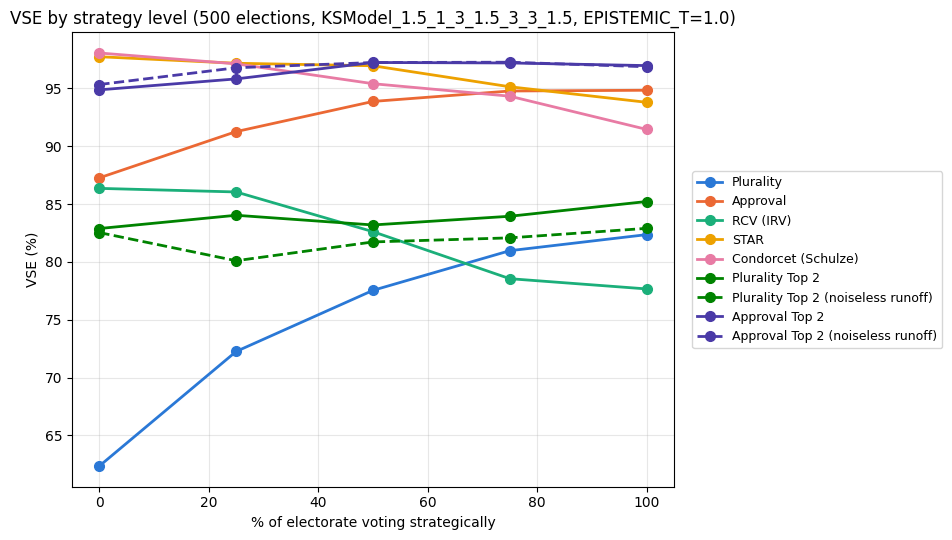

In [24]:
STRATEGY_AXIS = {
    "100% honest": 0,
    "25% strategic": 25,
    "50% strategic": 50,
    "75% strategic": 75,
    "100% strategic": 100,
}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in METHODS:
    points = sorted(
        (STRATEGY_AXIS[chooser_label], mean_)
        for chooser_label, mean_, _ in rows_by_method[label]
        if chooser_label in STRATEGY_AXIS
    )
    if not points:
        continue
    xs, ys = zip(*points)
    ax.plot(xs, [y * 100 for y in ys], marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)

ax.set_xlabel("% of electorate voting strategically")
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE by strategy level ({NITER} elections, {MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Range view: VSE across the full strategy sweep

Same `rows_by_method` data as the per-method tables in Section 10, but as a dot/range plot instead
of a line chart — one row per method, one dot per chooser (all 8 `baseRuns` variants, including the
one-sided/mixed choosers the line chart above skips), a thin line spanning that method's min-to-max
VSE across the whole sweep (the same span already reported as text in Sections 9/10, e.g.
"83.12% - 94.84%" for Approval). The honest-ballot point is marked distinctly (larger, outlined) as
the natural no-strategy reference point on each row. Rows are sorted by honest VSE, best at top.


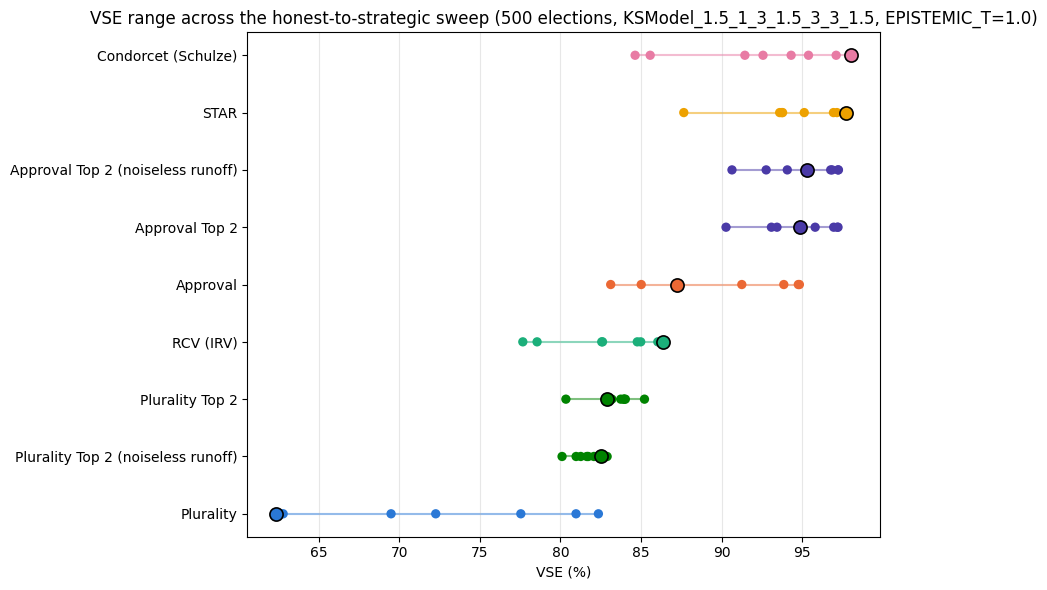

In [25]:
_sorted_labels = sorted(
    (label for label, _ in METHODS),
    key=lambda label: next(m for c, m, _ in rows_by_method[label] if c == "100% honest"),
)

fig, ax = plt.subplots(figsize=(9, 6))
# _sorted_labels is ascending by honest VSE; plotting in that order puts the worst method at
# row 0 (the bottom of a matplotlib y-axis) and the best method at the top row, as intended.
for row_i, label in enumerate(_sorted_labels):
    vses = [mean_ * 100 for _, mean_, _ in rows_by_method[label]]
    color = METHOD_COLORS[label]
    ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
    for chooser_label, mean_, _ in rows_by_method[label]:
        is_honest = chooser_label == "100% honest"
        ax.scatter(mean_ * 100, row_i,
                   s=90 if is_honest else 45,
                   color=color,
                   edgecolors="black" if is_honest else "none",
                   linewidths=1.2 if is_honest else 0,
                   zorder=3 if is_honest else 2)

ax.set_yticks(range(len(_sorted_labels)))
ax.set_yticklabels(_sorted_labels)
ax.set_xlabel("VSE (%)")
ax.set_title(f"VSE range across the honest-to-strategic sweep ({NITER} elections, "
             f"{MODEL}, EPISTEMIC_T={EPISTEMIC_T})")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


## 13. Epistemic noise: VSE vs. voter information (honest & strategic)

Sweep `EPISTEMIC_T` and re-run VSE for each method, for both the **honest** ballot and the **100%
strategic** ballot, to see how much simply *being uncertain about your own preferences*
(independent of strategic behavior) erodes outcome quality — and whether that erosion looks
different for methods where honest and strategic don't behave the same way (see the Approval note
in Section 8: Approval's strategic ballot actually *outperforms* its honest one, the opposite of
Score(10)). Uses a smaller `SWEEP_NITER` than the main run above to keep this quick — expect
noisier per-point estimates. Two panels, sharing a y-axis, so the shapes are directly comparable;
each method keeps the same color as every other chart in this notebook (`METHOD_COLORS` above).


t=0.30 done


t=0.50 done


t=0.70 done


t=0.85 done


t=1.00 done


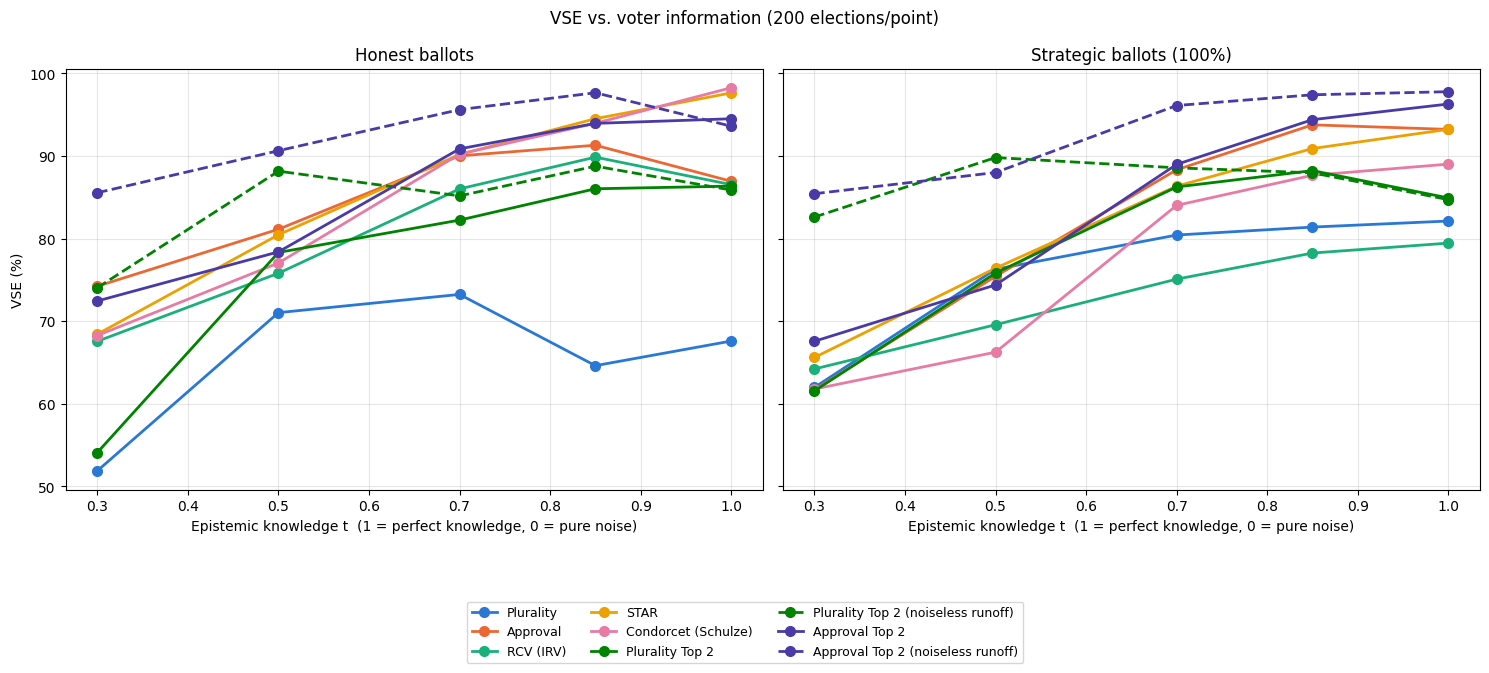

In [26]:
SWEEP_NITER = 200
T_VALUES = [0.3, 0.5, 0.7, 0.85, 1.0]

sweep_results_by_t = {}  # t -> {(label, chooser): (mean, ci)} -- the full breakdown, kept
                          # around so Section 11's range table can reuse it without re-running.
sweep_ce_by_t = {}       # t -> {(label, chooser): raw_ce}
sweep_rel_ce_by_t = {}   # t -> {(label, chooser): relative_ce}
noise_sweep_honest = {label: [] for label, _ in METHODS}
noise_sweep_strategic = {label: [] for label, _ in METHODS}
for t in T_VALUES:
    sweep_summary, sweep_ce_raw = run_vse_simulation(MODEL, METHODS, NVOT, NCAND, SWEEP_NITER, CHOOSER_FUNS, MEDIA, epistemic_t=t)
    sweep_results = reduce_to_mean_ci(sweep_summary)
    sweep_results_by_t[t] = sweep_results
    sweep_ce_by_t[t] = reduce_to_ce(sweep_ce_raw, sweep_results.keys())
    sweep_rel_ce_by_t[t] = relative_ce(sweep_ce_by_t[t])
    for label, _ in METHODS:
        honest_mean, honest_ci = sweep_results[(label, "honBallot")]
        strat_mean, strat_ci = sweep_results[(label, "stratBallot")]
        noise_sweep_honest[label].append((t, honest_mean, honest_ci))
        noise_sweep_strategic[label].append((t, strat_mean, strat_ci))
    print(f"t={t:.2f} done")

fig, (ax_hon, ax_strat) = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for label, _ in METHODS:
    color = METHOD_COLORS[label]
    style = METHOD_LINESTYLES[label]

    hon_ts = [t for t, _, _ in noise_sweep_honest[label]]
    hon_vses = [v * 100 for _, v, _ in noise_sweep_honest[label]]
    ax_hon.plot(hon_ts, hon_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)

    strat_ts = [t for t, _, _ in noise_sweep_strategic[label]]
    strat_vses = [v * 100 for _, v, _ in noise_sweep_strategic[label]]
    ax_strat.plot(strat_ts, strat_vses, marker="o", markersize=7, linewidth=2, color=color, linestyle=style, label=label)

ax_hon.set_title("Honest ballots")
ax_strat.set_title("Strategic ballots (100%)")
for ax in (ax_hon, ax_strat):
    ax.set_xlabel("Epistemic knowledge t  (1 = perfect knowledge, 0 = pure noise)")
    ax.grid(True, alpha=0.3)
ax_hon.set_ylabel("VSE (%)")

handles, labels_ = ax_hon.get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", fontsize=9, ncol=3, bbox_to_anchor=(0.5, -0.22))
fig.suptitle(f"VSE vs. voter information ({SWEEP_NITER} elections/point)")
plt.tight_layout()
plt.show()


### Condorcet efficiency vs. voter information (honest ballots)

Same sweep as above, reused rather than re-run: raw CE per method as epistemic knowledge `t`
degrades, honest ballots only (CE isn't defined per-election unless a true CW exists that
election, so this is P(elect CW | CW exists) at each `t`, not a per-election quantity).

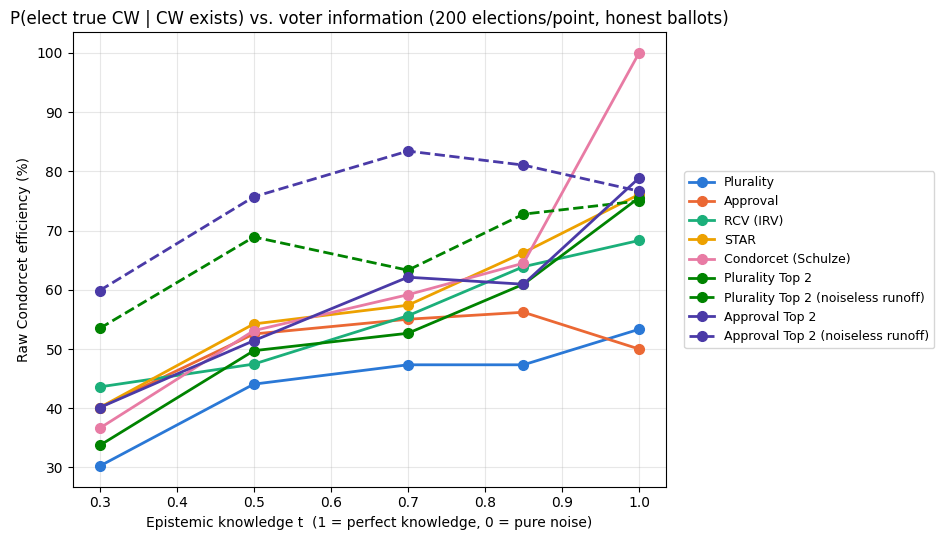

In [27]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _ in METHODS:
    ts = sorted(sweep_ce_by_t)
    ces = [sweep_ce_by_t[t].get((label, "honBallot"), float("nan")) * 100 for t in ts]
    ax.plot(ts, ces, marker="o", markersize=7, linewidth=2,
            color=METHOD_COLORS[label], linestyle=METHOD_LINESTYLES[label], label=label)
ax.set_xlabel("Epistemic knowledge t  (1 = perfect knowledge, 0 = pure noise)")
ax.set_ylabel("Raw Condorcet efficiency (%)")
ax.set_title(f"P(elect true CW | CW exists) vs. voter information ({SWEEP_NITER} elections/point, honest ballots)")
ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 14. VSE range by epistemic knowledge (t)

For each method, how much does VSE vary across *strategy levels* (honest through fully
strategic, including the one-sided/mixed variants), at a given level of voter information `t`?
Reuses the sweep from Section 10 above — no new simulation.

This orientation (fix `t`, range over strategy) rather than the opposite (fix strategy, range
over `t`) directly extends the "VSE range" convention already used in Section 8 and in the
original project's docs (e.g. "STAR: 91-98%") — those documented ranges are exactly this
table's `t=1.00` column. Reading down a column answers "how much does strategic behavior
matter, at this level of voter information?"; reading across a row answers "does that
strategy-sensitivity shrink or grow as voters get less informed?" (The other framing is the
same data transposed — Section 10's two-panel chart already tells that story directly for
honest vs. 100% strategic.)


In [28]:
header_cells = ["Method"] + [f"t={t:.2f}" for t in T_VALUES]
lines = [
    "| " + " | ".join(header_cells) + " |",
    "|" + "---|" * len(header_cells),
]
for label, _ in METHODS:
    row_cells = [label]
    for t in T_VALUES:
        vses = [mean_ for (lbl, chooser), (mean_, ci) in sweep_results_by_t[t].items() if lbl == label]
        lo, hi = min(vses) * 100, max(vses) * 100
        row_cells.append(f"{lo:.1f}-{hi:.1f}%")
    lines.append("| " + " | ".join(row_cells) + " |")

display(Markdown("\n".join(lines)))


| Method | t=0.30 | t=0.50 | t=0.70 | t=0.85 | t=1.00 |
|---|---|---|---|---|---|
| Plurality | 40.9-64.1% | 43.5-76.3% | 56.1-80.4% | 52.3-81.4% | 65.4-82.1% |
| Approval | 51.1-74.2% | 71.0-81.1% | 81.0-90.0% | 82.4-93.8% | 85.0-93.9% |
| RCV (IRV) | 63.2-68.5% | 67.1-76.1% | 75.1-86.0% | 78.3-89.9% | 77.9-87.8% |
| STAR | 49.6-70.2% | 70.4-80.5% | 82.6-90.7% | 87.4-94.5% | 89.1-97.6% |
| Condorcet (Schulze) | 48.9-68.9% | 65.0-77.0% | 77.5-90.2% | 81.1-94.0% | 82.1-98.3% |
| Plurality Top 2 | 54.1-64.5% | 74.6-78.3% | 82.2-87.1% | 83.6-88.9% | 82.1-87.5% |
| Plurality Top 2 (noiseless runoff) | 74.1-83.3% | 85.3-89.8% | 85.2-89.8% | 86.1-90.4% | 83.5-86.6% |
| Approval Top 2 | 63.2-72.4% | 72.7-78.4% | 87.3-90.9% | 91.1-94.8% | 93.2-98.1% |
| Approval Top 2 (noiseless runoff) | 81.2-87.8% | 84.8-92.1% | 93.2-96.1% | 94.1-97.7% | 90.5-97.8% |

## 15. Comparing method flavors: reusable tooling, then Approval's flavors vs. STAR/Schulze

With `EPISTEMIC_T`, `AWARENESS_L`, `FATIGUE_L`, and strategy level all in play, comparing any two
methods across any one of them was starting to mean writing a new sweep-and-chart cell every time
(the epistemic-noise sweep in Section 13 and the friction sweep that used to live here were
already two near-duplicate implementations). Instead: three small, reusable functions -- a sweep
runner and a table/chart pair -- that take a list of method *labels* (pulled from `METHODS_LOOKUP`,
so nothing new needs to be constructed) and which single parameter to sweep. Every comparison from
here on is a 3-line call instead of a new cell's worth of plumbing.


In [29]:
def sweep_methods(labels, sweep_param, sweep_values, niter, **fixed_overrides):
    """Run niter elections per value of sweep_param (one of 'epistemic_t', 'awareness_l',
    'fatigue_l'), holding the other two parameters at 1.0 (override via fixed_overrides),
    for just the given method labels (resolved against METHODS_LOOKUP).

    Returns (results_by_value, ce_by_value): each {value: {(label, chooser): ...}}, the same
    shape Sections 12/13 already use for EPISTEMIC_T, just generalized to any of the three
    parameters and any method subset. results_by_value holds (mean, ci) VSE pairs; ce_by_value
    holds raw Condorcet efficiency (checkpoint-4 addition).
    """
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    base_kwargs = dict(epistemic_t=1.0, awareness_l=1.0, fatigue_l=1.0)
    base_kwargs.update(fixed_overrides)
    results_by_value = {}
    ce_by_value = {}
    for value in sweep_values:
        kwargs = dict(base_kwargs)
        kwargs[sweep_param] = value
        summary, ce_raw = run_vse_simulation(MODEL, methods_subset, NVOT, NCAND, niter,
                                      CHOOSER_FUNS, MEDIA, **kwargs)
        results_by_value[value] = reduce_to_mean_ci(summary)
        ce_by_value[value] = reduce_to_ce(ce_raw, results_by_value[value].keys())
        print(f"{sweep_param}={value:.2f} done")
    return results_by_value, ce_by_value


def comparison_table(results_by_value, labels, sweep_param, ballot_type="honBallot"):
    """Markdown table: rows=label, columns=sweep_param values, cell=VSE% (+/- CI)."""
    values = sorted(results_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in labels:
        row = [label]
        for v in values:
            mean_, ci = results_by_value[v][(label, ballot_type)]
            row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))


def comparison_chart(results_by_value, labels, sweep_param, ballot_type="honBallot",
                      baseline_label=None, title=None):
    """VSE-vs-sweep_param line chart; if baseline_label is given, a second panel shows
    label - baseline for every other label (the 'flip it ... minus STAR' framing)."""
    values = sorted(results_by_value)
    ncols = 2 if baseline_label else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    ax_vse = axes[0] if baseline_label else axes
    for label in labels:
        vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
        ax_vse.plot(values, vses, marker="o", markersize=7, linewidth=2,
                    color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                    label=label)
    ax_vse.set_xlabel(sweep_param)
    ax_vse.set_ylabel("VSE (%)")
    ax_vse.set_title(title or f"VSE vs. {sweep_param}")
    ax_vse.legend(fontsize=8)
    ax_vse.grid(True, alpha=0.3)

    if baseline_label:
        ax_gap = axes[1]
        baseline_vses = [results_by_value[v][(baseline_label, ballot_type)][0] * 100 for v in values]
        for label in labels:
            if label == baseline_label:
                continue
            vses = [results_by_value[v][(label, ballot_type)][0] * 100 for v in values]
            gap = [a - b for a, b in zip(vses, baseline_vses)]
            ax_gap.plot(values, gap, marker="o", markersize=7, linewidth=2,
                        color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"),
                        label=f"{label} \u2212 {baseline_label}")
        ax_gap.axhline(0, color="gray", linewidth=1, linestyle=":")
        ax_gap.set_xlabel(sweep_param)
        ax_gap.set_ylabel("VSE gap (percentage points)")
        ax_gap.set_title(f"Gap vs. {baseline_label}")
        ax_gap.legend(fontsize=8)
        ax_gap.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


### Approval's flavors vs. STAR/Schulze, across noise and both friction mechanisms

The motivating question: Approval Top 2 (a coarse 0/1 ballot, decided over two rounds) is the
flavor of Approval actually being adopted (e.g. St. Louis). STAR and Schulze both let voters
express far more information in a single round. Does STAR/Schulze's honest-VSE edge over Approval
hold up once that richer signal degrades -- and does Approval Top 2's *delayed, two-candidate*
runoff let voters recover some of that edge, on the theory that deciding between just two finalists
is easy to get right even if the crowded primary wasn't?

Same `baseline_label="STAR"` framing, for all three parameters in turn -- `EPISTEMIC_T`,
`AWARENESS_L`, `FATIGUE_L` -- each swept alone with the other two held at `1.0`. Plurality and RCV
are included alongside the Approval flavors and STAR/Schulze for reference -- the two methods
without any "richer signal" to lose, so they're a useful floor/comparison point for how much the
other methods' edge is really coming from their richer ballots versus just from the electorate
model itself. `COMPARE_NITER` is smaller than the main run to keep three separate sweeps
tractable; expect this cell to take a minute or two.


In [30]:
COMPARE_LABELS = ["Plurality", "RCV (IRV)", "Approval", "Approval Top 2",
                   "Approval Top 2 (noiseless runoff)", "STAR", "Condorcet (Schulze)"]
COMPARE_NITER = 150
COMPARE_VALUES = [0.0, 0.3, 0.5, 0.7, 0.85, 1.0]

compare_by_param = {}
compare_ce_by_param = {}
for sweep_param in ("epistemic_t", "awareness_l", "fatigue_l"):
    compare_by_param[sweep_param], compare_ce_by_param[sweep_param] = sweep_methods(
        COMPARE_LABELS, sweep_param, COMPARE_VALUES, COMPARE_NITER
    )


epistemic_t=0.00 done


epistemic_t=0.30 done


epistemic_t=0.50 done


epistemic_t=0.70 done


epistemic_t=0.85 done


...

fatigue_l=0.30 done


fatigue_l=0.50 done


fatigue_l=0.70 done


fatigue_l=0.85 done


fatigue_l=1.00 done


#### Epistemic noise (EPISTEMIC_T)

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 3.1% (+/-17.8) | 59.4% (+/-8.9) | 71.7% (+/-7.3) | 66.4% (+/-11.3) | 70.4% (+/-9.1) | 65.1% (+/-10.7) |
| RCV (IRV) | 11.0% (+/-16.8) | 65.7% (+/-7.3) | 78.9% (+/-5.6) | 89.3% (+/-3.9) | 90.8% (+/-3.9) | 88.2% (+/-3.9) |
| Approval | 10.6% (+/-17.1) | 66.6% (+/-6.3) | 79.5% (+/-5.3) | 89.3% (+/-3.1) | 93.3% (+/-2.2) | 87.5% (+/-3.4) |
| Approval Top 2 | 5.3% (+/-17.7) | 70.3% (+/-7.0) | 82.0% (+/-5.1) | 89.9% (+/-3.1) | 93.9% (+/-2.0) | 94.3% (+/-2.2) |
| Approval Top 2 (noiseless runoff) | 65.4% (+/-8.5) | 82.8% (+/-5.9) | 91.9% (+/-3.4) | 95.8% (+/-1.7) | 96.1% (+/-1.6) | 95.0% (+/-2.1) |
| STAR | 10.9% (+/-17.7) | 69.2% (+/-6.7) | 81.2% (+/-5.2) | 89.9% (+/-3.8) | 95.4% (+/-1.9) | 96.9% (+/-1.5) |
| Condorcet (Schulze) | 17.1% (+/-17.4) | 71.3% (+/-7.0) | 79.8% (+/-5.0) | 91.5% (+/-3.1) | 95.5% (+/-1.6) | 99.0% (+/-0.9) |

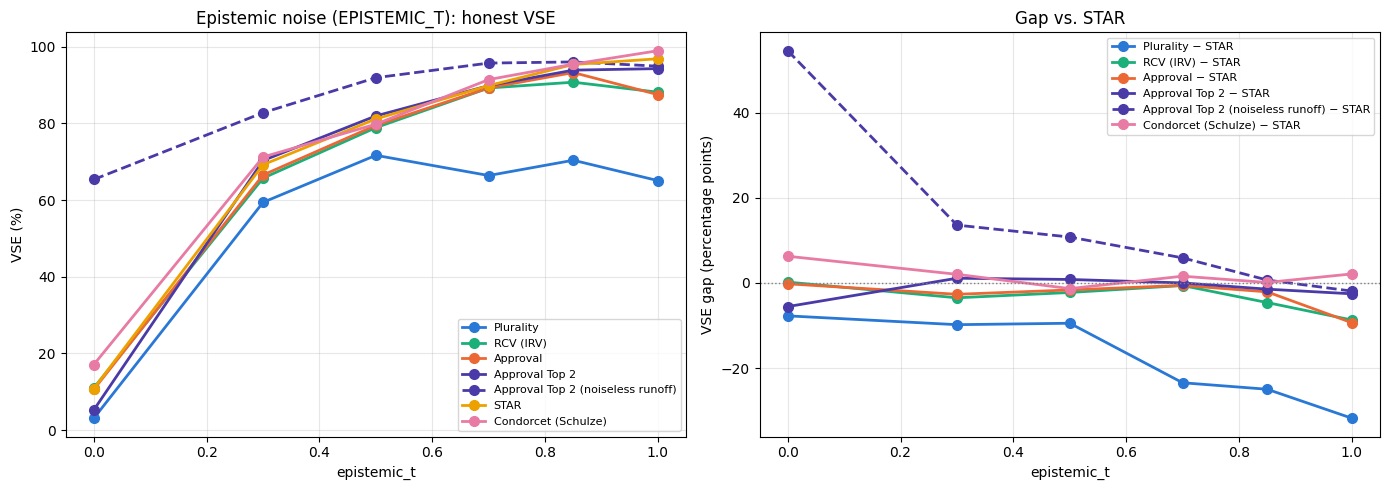

#### Unfamiliarity (AWARENESS_L)

| Method | awareness_l=0.00 | awareness_l=0.30 | awareness_l=0.50 | awareness_l=0.70 | awareness_l=0.85 | awareness_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 8.4% (+/-15.1) | 5.5% (+/-15.3) | 1.4% (+/-16.3) | 49.4% (+/-12.4) | 53.2% (+/-13.0) | 65.5% (+/-8.9) |
| RCV (IRV) | 8.4% (+/-15.1) | 5.5% (+/-15.3) | -7.0% (+/-16.9) | 46.0% (+/-13.2) | 61.0% (+/-10.1) | 87.1% (+/-4.3) |
| Approval | 8.4% (+/-15.1) | 6.7% (+/-15.3) | 23.1% (+/-14.6) | 64.6% (+/-8.5) | 78.3% (+/-5.3) | 89.1% (+/-3.4) |
| Approval Top 2 | 8.4% (+/-15.1) | 5.5% (+/-15.3) | -1.2% (+/-16.4) | 61.4% (+/-7.9) | 70.7% (+/-7.0) | 94.2% (+/-2.4) |
| Approval Top 2 (noiseless runoff) | 61.1% (+/-7.6) | 60.8% (+/-8.8) | 50.4% (+/-11.8) | 78.9% (+/-6.0) | 86.2% (+/-4.5) | 95.1% (+/-2.0) |
| STAR | 8.4% (+/-15.1) | 5.5% (+/-15.3) | 11.4% (+/-15.7) | 67.6% (+/-7.0) | 76.7% (+/-6.0) | 96.7% (+/-1.6) |
| Condorcet (Schulze) | 8.4% (+/-15.1) | 5.5% (+/-15.3) | -8.2% (+/-17.0) | 43.2% (+/-13.5) | 68.5% (+/-7.2) | 98.1% (+/-1.3) |

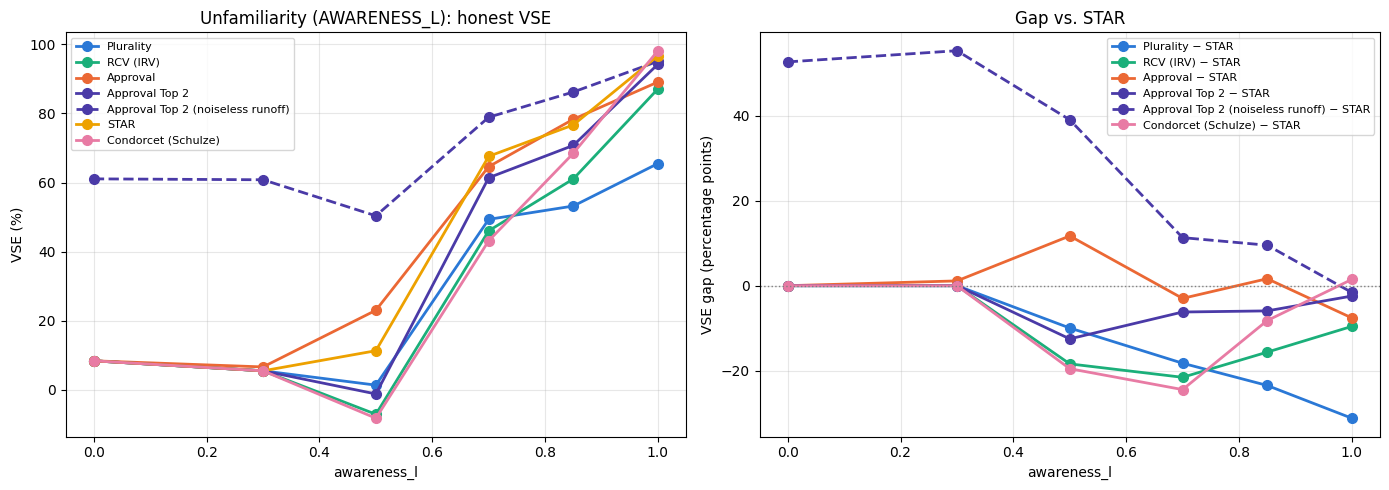

#### Ballot fatigue (FATIGUE_L)

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 7.1% (+/-16.5) | 38.7% (+/-13.7) | 64.2% (+/-8.1) | 72.8% (+/-6.3) | 74.4% (+/-9.4) | 67.0% (+/-9.5) |
| RCV (IRV) | -9.4% (+/-18.3) | 17.8% (+/-14.2) | 46.3% (+/-12.1) | 64.5% (+/-7.8) | 79.8% (+/-6.9) | 86.5% (+/-5.4) |
| Approval | -1.7% (+/-17.6) | 44.2% (+/-11.9) | 66.6% (+/-8.0) | 80.4% (+/-4.7) | 83.9% (+/-4.3) | 86.8% (+/-3.7) |
| Approval Top 2 | -13.5% (+/-18.5) | 35.8% (+/-12.0) | 57.2% (+/-9.1) | 78.4% (+/-5.1) | 87.6% (+/-3.9) | 94.7% (+/-2.0) |
| Approval Top 2 (noiseless runoff) | 55.7% (+/-8.7) | 71.5% (+/-7.6) | 85.4% (+/-4.7) | 91.1% (+/-3.2) | 94.0% (+/-3.2) | 94.8% (+/-2.0) |
| STAR | 1.1% (+/-18.5) | 30.0% (+/-13.3) | 64.7% (+/-8.2) | 79.2% (+/-5.3) | 88.7% (+/-4.0) | 97.0% (+/-1.7) |
| Condorcet (Schulze) | -2.2% (+/-17.8) | 4.7% (+/-16.4) | 25.7% (+/-14.6) | 65.5% (+/-8.1) | 87.3% (+/-4.1) | 97.8% (+/-1.5) |

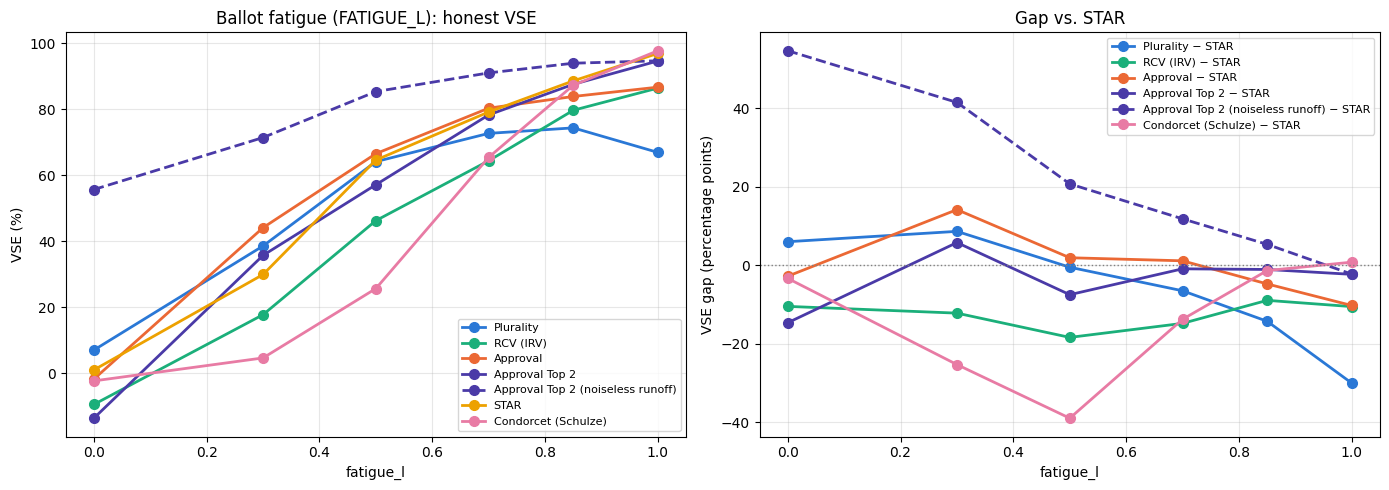

In [31]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_l", "Unfamiliarity (AWARENESS_L)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title}"))
    comparison_table(compare_by_param[sweep_param], COMPARE_LABELS, sweep_param)
    comparison_chart(compare_by_param[sweep_param], COMPARE_LABELS, sweep_param,
                      baseline_label="STAR", title=f"{param_title}: honest VSE")


### Condorcet efficiency across the same three individual sweeps

Reuses `compare_ce_by_param` from the sweep above -- no new simulation. Raw CE (honest ballots)
per method, per sweep parameter.

#### Epistemic noise (EPISTEMIC_T): raw Condorcet efficiency

| Method | epistemic_t=0.00 | epistemic_t=0.30 | epistemic_t=0.50 | epistemic_t=0.70 | epistemic_t=0.85 | epistemic_t=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 15.1% | 27.3% | 38.3% | 48.0% | 58.3% | 50.8% |
| RCV (IRV) | 18.3% | 33.8% | 43.8% | 57.5% | 65.9% | 66.2% |
| Approval | 19.0% | 30.9% | 45.3% | 52.8% | 65.2% | 56.9% |
| Approval Top 2 | 16.7% | 33.1% | 50.8% | 54.3% | 64.4% | 78.5% |
| Approval Top 2 (noiseless runoff) | 40.5% | 54.7% | 74.2% | 75.6% | 78.0% | 78.5% |
| STAR | 16.7% | 32.4% | 49.2% | 59.8% | 72.7% | 80.8% |
| Condorcet (Schulze) | 21.4% | 38.1% | 42.2% | 62.2% | 72.0% | 100.0% |

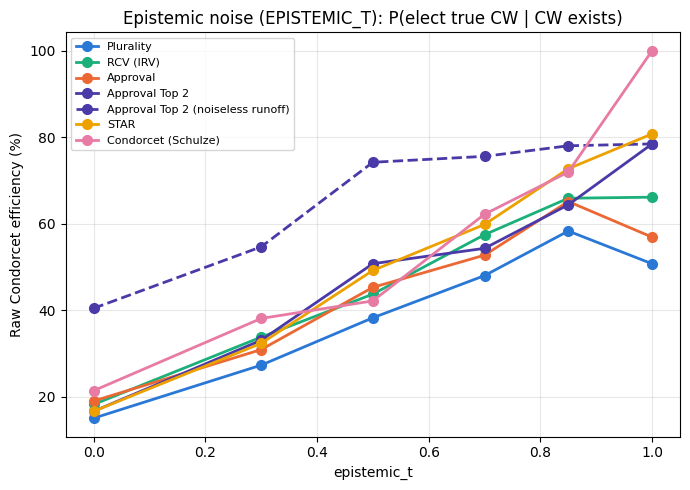

#### Unfamiliarity (AWARENESS_L): raw Condorcet efficiency

| Method | awareness_l=0.00 | awareness_l=0.30 | awareness_l=0.50 | awareness_l=0.70 | awareness_l=0.85 | awareness_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 18.5% | 15.4% | 16.4% | 24.8% | 37.3% | 44.5% |
| RCV (IRV) | 18.5% | 15.4% | 14.9% | 23.4% | 36.6% | 67.2% |
| Approval | 18.5% | 15.4% | 20.9% | 26.3% | 40.3% | 57.0% |
| Approval Top 2 | 18.5% | 15.4% | 16.4% | 22.6% | 40.3% | 75.8% |
| Approval Top 2 (noiseless runoff) | 28.5% | 38.5% | 38.8% | 45.3% | 61.9% | 77.3% |
| STAR | 18.5% | 15.4% | 18.7% | 27.0% | 42.5% | 74.2% |
| Condorcet (Schulze) | 18.5% | 15.4% | 14.9% | 21.2% | 37.3% | 100.0% |

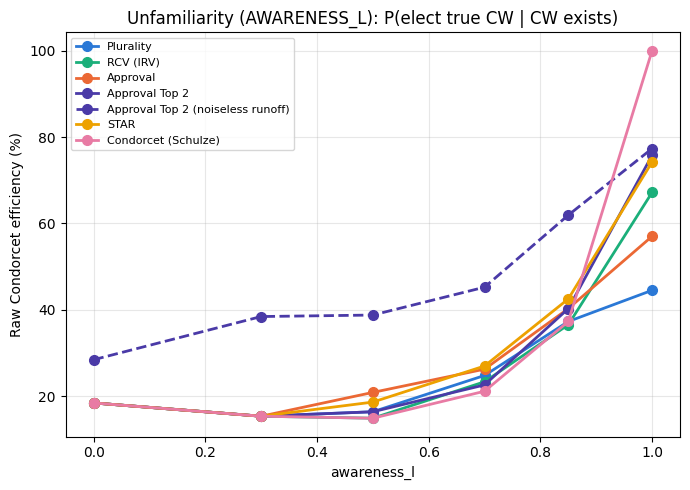

#### Ballot fatigue (FATIGUE_L): raw Condorcet efficiency

| Method | fatigue_l=0.00 | fatigue_l=0.30 | fatigue_l=0.50 | fatigue_l=0.70 | fatigue_l=0.85 | fatigue_l=1.00 |
|---|---|---|---|---|---|---|
| Plurality | 19.3% | 28.2% | 32.1% | 40.0% | 53.4% | 50.4% |
| RCV (IRV) | 18.5% | 15.3% | 29.2% | 35.4% | 56.5% | 71.0% |
| Approval | 23.0% | 24.4% | 32.1% | 41.5% | 48.1% | 58.8% |
| Approval Top 2 | 20.0% | 23.7% | 29.9% | 40.0% | 57.3% | 77.9% |
| Approval Top 2 (noiseless runoff) | 35.6% | 42.0% | 54.0% | 68.5% | 74.8% | 76.3% |
| STAR | 24.4% | 21.4% | 30.7% | 41.5% | 57.3% | 82.4% |
| Condorcet (Schulze) | 18.5% | 16.8% | 21.2% | 36.2% | 64.1% | 100.0% |

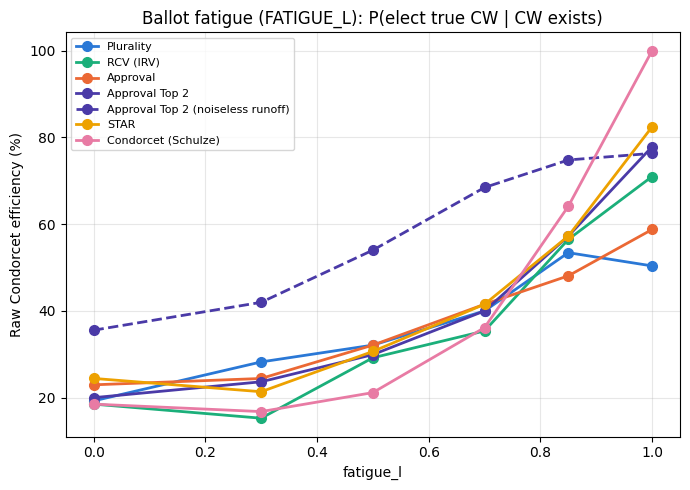

In [32]:
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise (EPISTEMIC_T)"),
    ("awareness_l", "Unfamiliarity (AWARENESS_L)"),
    ("fatigue_l", "Ballot fatigue (FATIGUE_L)"),
]:
    display(Markdown(f"#### {param_title}: raw Condorcet efficiency"))
    ce_by_value = compare_ce_by_param[sweep_param]
    values = sorted(ce_by_value)
    header = ["Method"] + [f"{sweep_param}={v:.2f}" for v in values]
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    for label in COMPARE_LABELS:
        row = [label]
        for v in values:
            ce = ce_by_value[v].get((label, "honBallot"))
            row.append("n/a" if ce is None or ce != ce else f"{ce * 100:.1f}%")
        lines.append("| " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for label in COMPARE_LABELS:
        ces = [ce_by_value[v].get((label, "honBallot"), float("nan")) * 100 for v in values]
        ax.plot(values, ces, marker="o", markersize=7, linewidth=2,
                color=METHOD_COLORS.get(label), linestyle=METHOD_LINESTYLES.get(label, "-"), label=label)
    ax.set_xlabel(sweep_param)
    ax.set_ylabel("Raw Condorcet efficiency (%)")
    ax.set_title(f"{param_title}: P(elect true CW | CW exists)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [33]:
# Plain-language readout: does each Approval flavor's gap to STAR shrink, hold, or reverse?
_narrowing_lines = [
    "| Parameter | Method | Gap @ full (pp) | Gap @ max friction (pp) | Direction |",
    "|---|---|---|---|---|",
]
for sweep_param, param_title in [
    ("epistemic_t", "Epistemic noise"),
    ("awareness_l", "Unfamiliarity"),
    ("fatigue_l", "Ballot fatigue"),
]:
    results_by_value = compare_by_param[sweep_param]
    star_at = {v: results_by_value[v][("STAR", "honBallot")][0] for v in results_by_value}
    for label in ("Approval", "Approval Top 2", "Approval Top 2 (noiseless runoff)"):
        label_at = {v: results_by_value[v][(label, "honBallot")][0] for v in results_by_value}
        gap_full = (label_at[1.0] - star_at[1.0]) * 100
        gap_max_friction = (label_at[0.0] - star_at[0.0]) * 100
        # "Narrowing" means STAR's lead shrinks -- i.e. the gap (label - STAR) moves UP, toward
        # or past zero -- not whether |gap| shrinks. A move from "STAR ahead by 10" to "label
        # ahead by 12" is a narrowing (and then a reversal), not a widening, even though the
        # absolute size of the gap grew.
        if gap_max_friction > gap_full:
            direction = "narrowed, and reversed (now ahead of STAR)" if gap_max_friction > 0 else "narrowed"
        elif gap_max_friction < gap_full:
            direction = "widened"
        else:
            direction = "unchanged"
        _narrowing_lines.append(
            f"| {param_title} | {label} | {gap_full:+.1f} | {gap_max_friction:+.1f} | {direction} |"
        )
display(Markdown("\n".join(_narrowing_lines)))


| Parameter | Method | Gap @ full (pp) | Gap @ max friction (pp) | Direction |
|---|---|---|---|---|
| Epistemic noise | Approval | -9.4 | -0.2 | narrowed |
| Epistemic noise | Approval Top 2 | -2.6 | -5.6 | widened |
| Epistemic noise | Approval Top 2 (noiseless runoff) | -1.9 | +54.5 | narrowed, and reversed (now ahead of STAR) |
| Unfamiliarity | Approval | -7.6 | +0.0 | narrowed |
| Unfamiliarity | Approval Top 2 | -2.4 | +0.0 | narrowed |
| Unfamiliarity | Approval Top 2 (noiseless runoff) | -1.6 | +52.6 | narrowed, and reversed (now ahead of STAR) |
| Ballot fatigue | Approval | -10.2 | -2.8 | narrowed |
| Ballot fatigue | Approval Top 2 | -2.3 | -14.6 | widened |
| Ballot fatigue | Approval Top 2 (noiseless runoff) | -2.2 | +54.7 | narrowed, and reversed (now ahead of STAR) |

### Joint "realistic conditions": all three degradation parameters at once

Every sweep above holds two of `EPISTEMIC_T`/`AWARENESS_L`/`FATIGUE_L` at their ideal value (`1.0`)
while moving the third. That isolates each mechanism cleanly, but no real election holds two of
the three perfectly -- voters are simultaneously somewhat uncertain about their own preferences,
somewhat unfamiliar with minor candidates, and somewhat prone to not finishing a long ballot. STAR
and Schulze's honest-VSE edge over Approval's flavors was built entirely on the assumption that all
three hold at once (Section 9's main run: `EPISTEMIC_T=AWARENESS_L=FATIGUE_L=1.0`). This section
asks what's left of that edge once none of the three ideal assumptions hold simultaneously, and
puts a number on it rather than reading it off three separate charts.

Four fixed scenarios (not swept, all three parameters move together), same
`COMPARE_LABELS` as above, honest ballots only (strategy held fixed, same as every comparison in
Section 15):


In [34]:
JOINT_SCENARIOS = {
    "Ideal":              {"epistemic_t": 1.0,  "awareness_l": 1.0,  "fatigue_l": 1.0},
    "Mild friction":      {"epistemic_t": 0.85, "awareness_l": 0.85, "fatigue_l": 0.85},
    "Moderate friction":  {"epistemic_t": 0.7,  "awareness_l": 0.7,  "fatigue_l": 0.7},
    "Heavy friction":     {"epistemic_t": 0.5,  "awareness_l": 0.5,  "fatigue_l": 0.5},
}
JOINT_NITER = 350  # only 4 runs total here (vs. Section 15's 18), so we can afford tighter CIs


def run_joint_scenarios(labels, scenarios, niter):
    """scenarios: {scenario_name: {epistemic_t, awareness_l, fatigue_l}} (missing keys default
    to 1.0). Returns (results_by_scenario, ce_by_scenario), each {scenario_name: {(label,
    chooser): ...}} -- same shape sweep_methods returns, just keyed by scenario name instead of
    a swept parameter value. results_by_scenario holds (mean, ci) VSE pairs; ce_by_scenario
    holds raw Condorcet efficiency (checkpoint-4 addition)."""
    methods_subset = [(label, METHODS_LOOKUP[label]) for label in labels]
    results_by_scenario = {}
    ce_by_scenario = {}
    for name, params in scenarios.items():
        kwargs = dict(epistemic_t=1.0, awareness_l=1.0, fatigue_l=1.0)
        kwargs.update(params)
        summary, ce_raw = run_vse_simulation(MODEL, methods_subset, NVOT, NCAND, niter,
                                      CHOOSER_FUNS, MEDIA, **kwargs)
        results_by_scenario[name] = reduce_to_mean_ci(summary)
        ce_by_scenario[name] = reduce_to_ce(ce_raw, results_by_scenario[name].keys())
        print(f"{name} done")
    return results_by_scenario, ce_by_scenario


joint_results, joint_ce_results = run_joint_scenarios(COMPARE_LABELS, JOINT_SCENARIOS, JOINT_NITER)


Ideal done


Mild friction done


Moderate friction done


Heavy friction done


| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 62.8% (+/-6.4) | 58.2% (+/-6.3) | 37.5% (+/-8.4) | 10.7% (+/-10.3) |
| RCV (IRV) | 87.9% (+/-3.2) | 51.7% (+/-6.3) | 21.3% (+/-10.1) | 7.5% (+/-10.7) |
| Approval | 88.6% (+/-2.1) | 68.3% (+/-4.5) | 41.8% (+/-7.8) | 22.0% (+/-9.4) |
| Approval Top 2 | 94.4% (+/-1.5) | 62.1% (+/-5.2) | 31.4% (+/-8.9) | 12.3% (+/-10.4) |
| Approval Top 2 (noiseless runoff) | 94.2% (+/-1.5) | 83.7% (+/-3.1) | 69.0% (+/-4.9) | 65.7% (+/-4.9) |
| STAR | 97.1% (+/-0.8) | 67.2% (+/-4.7) | 38.5% (+/-8.2) | 13.2% (+/-10.5) |
| Condorcet (Schulze) | 98.4% (+/-0.6) | 48.6% (+/-6.5) | 21.8% (+/-10.0) | 9.6% (+/-10.4) |

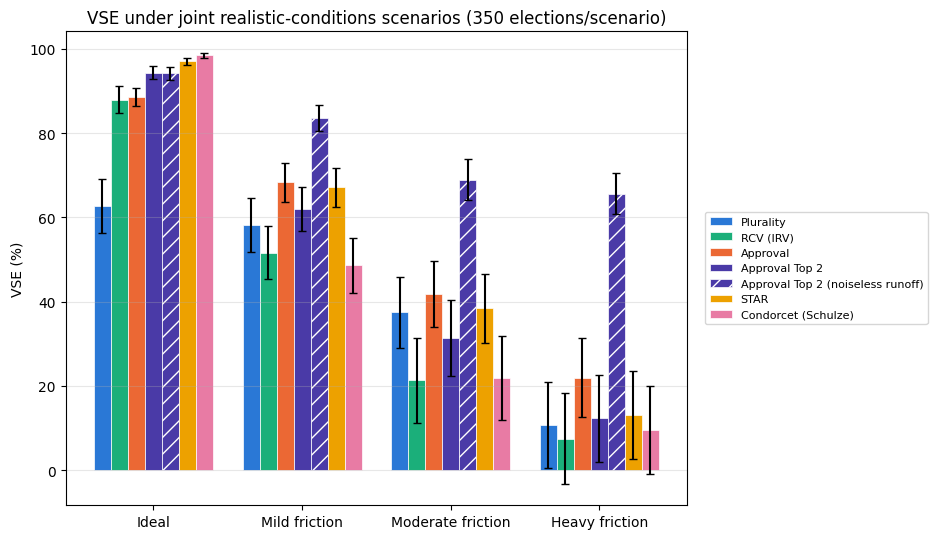

In [35]:
_scenario_names = list(JOINT_SCENARIOS)

# Table: rows = method, columns = scenario, cell = VSE% (+/-CI)
_joint_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                      "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        mean_, ci = joint_results[name][(label, "honBallot")]
        row.append(f"{mean_ * 100:.1f}% (+/-{ci * 100:.1f})")
    _joint_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method.
fig, ax = plt.subplots(figsize=(9.5, 5.5))
_n_labels = len(COMPARE_LABELS)
_bar_width = 0.8 / _n_labels
_x = np.arange(len(_scenario_names))
for i, label in enumerate(COMPARE_LABELS):
    vses = [joint_results[name][(label, "honBallot")][0] * 100 for name in _scenario_names]
    cis = [joint_results[name][(label, "honBallot")][1] * 100 for name in _scenario_names]
    hatch = "//" if "noiseless runoff" in label else None
    ax.bar(_x + i * _bar_width, vses, _bar_width, yerr=cis, capsize=3,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("VSE (%)")
ax.set_title(f"VSE under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Condorcet efficiency under the same joint realistic-conditions scenarios

This is the comparison the whole Condorcet-efficiency section was really built for: as noise,
unfamiliarity, and ballot fatigue all degrade *together*, does each method's ability to actually
elect the true Condorcet winner hold up -- and how does that compare to Schulze, the method
literally designed to find it?

| Method | Ideal | Mild friction | Moderate friction | Heavy friction |
|---|---|---|---|---|
| Plurality | 48.0% (0.48x Schulze) | 34.0% (1.37x Schulze) | 19.6% (1.16x Schulze) | 20.3% (1.00x Schulze) |
| RCV (IRV) | 67.9% (0.68x Schulze) | 27.9% (1.12x Schulze) | 17.6% (1.04x Schulze) | 21.0% (1.03x Schulze) |
| Approval | 55.7% (0.56x Schulze) | 35.0% (1.41x Schulze) | 21.3% (1.26x Schulze) | 22.6% (1.11x Schulze) |
| Approval Top 2 | 82.8% (0.83x Schulze) | 30.6% (1.23x Schulze) | 19.9% (1.18x Schulze) | 20.7% (1.02x Schulze) |
| Approval Top 2 (noiseless runoff) | 82.4% (0.82x Schulze) | 56.1% (2.26x Schulze) | 35.1% (2.08x Schulze) | 37.4% (1.84x Schulze) |
| STAR | 79.1% (0.79x Schulze) | 35.0% (1.41x Schulze) | 20.6% (1.22x Schulze) | 21.3% (1.05x Schulze) |
| Condorcet (Schulze) | 100.0% (1.00x Schulze) | 24.8% (1.00x Schulze) | 16.9% (1.00x Schulze) | 20.3% (1.00x Schulze) |

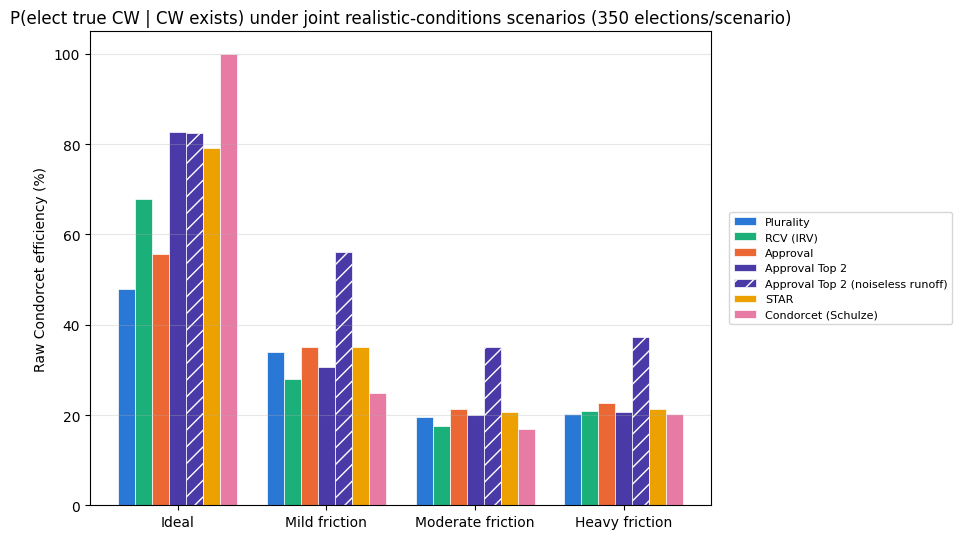

In [36]:
_joint_ce_table_lines = ["| Method | " + " | ".join(_scenario_names) + " |",
                         "|---|" + "---|" * len(_scenario_names)]
for label in COMPARE_LABELS:
    row = [label]
    for name in _scenario_names:
        raw = joint_ce_results[name].get((label, "honBallot"))
        rel = relative_ce(joint_ce_results[name]).get((label, "honBallot"))
        raw_str = "n/a" if raw is None or raw != raw else f"{raw * 100:.1f}%"
        rel_str = "" if rel is None else f" ({rel:.2f}x Schulze)"
        row.append(raw_str + rel_str)
    _joint_ce_table_lines.append("| " + " | ".join(row) + " |")
display(Markdown("\n".join(_joint_ce_table_lines)))

# Grouped bar chart: one group per scenario, one bar per method -- same layout as the VSE
# version above, but raw Condorcet efficiency instead of VSE (no error bars: CE has no CI
# computed here, unlike the VSE accumulator's mean/variance tracking).
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    ces = [
        (joint_ce_results[name].get((label, "honBallot")) or float("nan")) * 100
        for name in _scenario_names
    ]
    hatch = "//" if "noiseless runoff" in label else None
    ax.bar(_x + i * _bar_width, ces, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Raw Condorcet efficiency (%)")
ax.set_title(f"P(elect true CW | CW exists) under joint realistic-conditions scenarios ({JOINT_NITER} elections/scenario)")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Same layout as the raw-CE chart above, but relative to Schulze's own CE at each scenario --
# computed once here and reused, rather than recomputing relative_ce(...) per method per scenario.
joint_rel_ce_results = {name: relative_ce(joint_ce_results[name]) for name in _scenario_names}

fig, ax = plt.subplots(figsize=(9.5, 5.5))
for i, label in enumerate(COMPARE_LABELS):
    rels = [
        joint_rel_ce_results[name].get((label, "honBallot"), float("nan"))
        for name in _scenario_names
    ]
    hatch = "//" if "noiseless runoff" in label else None
    ax.bar(_x + i * _bar_width, rels, _bar_width,
           color=METHOD_COLORS[label], hatch=hatch, label=label, edgecolor="white", linewidth=0.5)
ax.axhline(1.0, color="gray", linewidth=1, linestyle=":")  # "same as Schulze"
ax.set_xticks(_x + _bar_width * (_n_labels - 1) / 2)
ax.set_xticklabels(_scenario_names)
ax.set_ylabel("Relative Condorcet efficiency (x Schulze)")
ax.set_title("CE relative to Schulze under joint realistic-conditions scenarios")
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Range view: the same joint scenarios, broken out by strategy level

Same idea as the range/dot plot in Section 8 (VSE across the full 8-`baseRuns`-chooser sweep,
one row per method), but small-multiples over the 4 joint scenarios instead of a single panel —
`run_joint_scenarios` already ran every chooser for every scenario (`run_vse_simulation` always
runs the full `baseRuns` battery), so this reuses `joint_results` exactly as computed above, no new
simulation. Row order is fixed across all four panels (methods sorted by honest VSE **at
`Ideal`**, not re-sorted per panel) so a given method's row stays in the same place as you read
left to right — otherwise a method whose rank changes between scenarios would jump rows and the
comparison would be unreadable. All four panels share one x-axis on purpose: the point is to see
the *whole cluster* visibly compress and slide left as friction compounds, which a per-panel
rescaled axis would hide. The dotted vertical line at 0% marks the random-baseline threshold
(worse than 0% VSE means worse than picking a winner at random).


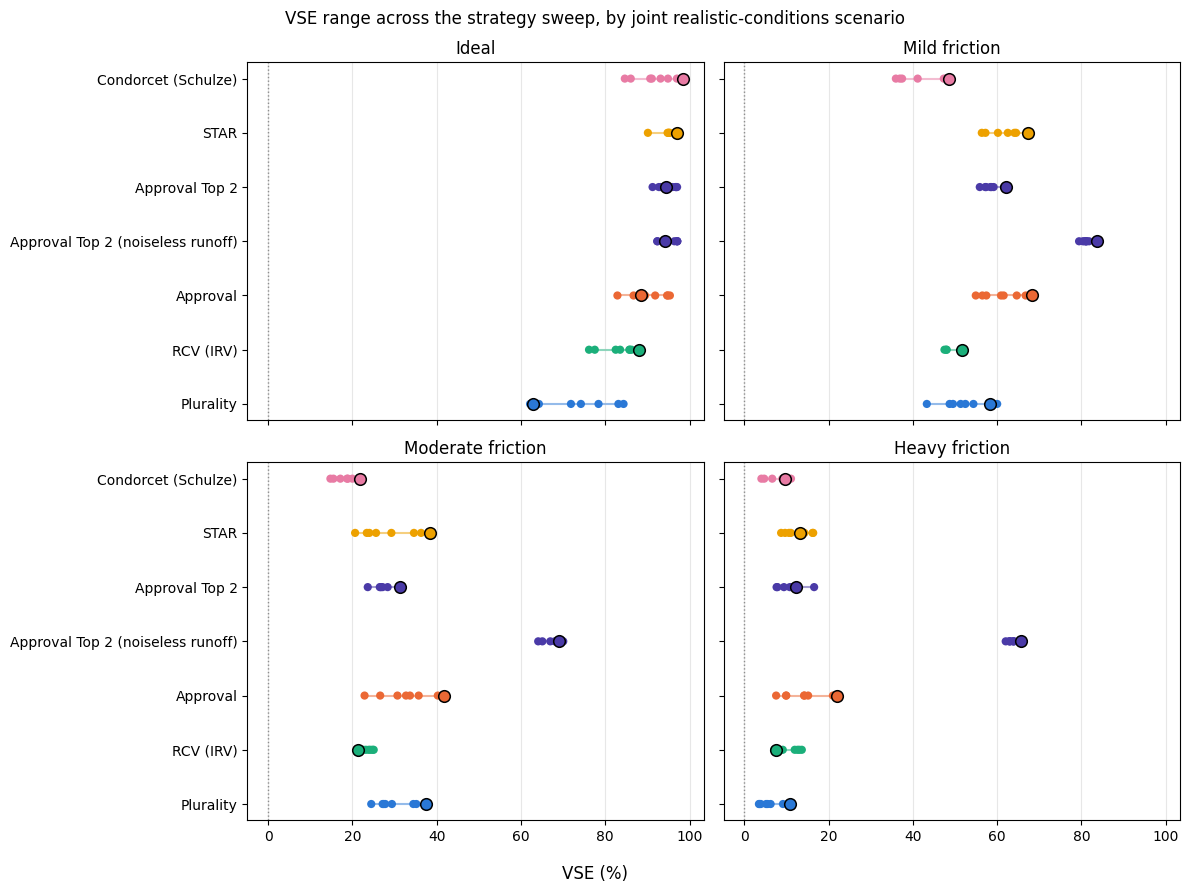

In [37]:
_joint_row_order = sorted(
    COMPARE_LABELS,
    key=lambda label: joint_results["Ideal"][(label, "honBallot")][0],
)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for panel_i, name in enumerate(_scenario_names):
    ax = axes.flat[panel_i]
    scenario_results = joint_results[name]
    for row_i, label in enumerate(_joint_row_order):
        color = METHOD_COLORS[label]
        vses = [mean_ * 100 for (lbl, chooser), (mean_, ci) in scenario_results.items() if lbl == label]
        ax.plot([min(vses), max(vses)], [row_i, row_i], color=color, linewidth=1.5, alpha=0.5, zorder=1)
        for (lbl, chooser), (mean_, ci) in scenario_results.items():
            if lbl != label:
                continue
            is_honest = chooser == "honBallot"
            ax.scatter(mean_ * 100, row_i,
                       s=70 if is_honest else 35,
                       color=color,
                       edgecolors="black" if is_honest else "none",
                       linewidths=1.1 if is_honest else 0,
                       zorder=3 if is_honest else 2)
    ax.axvline(0, color="gray", linewidth=1, linestyle=":", zorder=0)
    ax.set_title(name)
    ax.grid(True, axis="x", alpha=0.3)
    ax.label_outer()

axes.flat[0].set_yticks(range(len(_joint_row_order)))
axes.flat[0].set_yticklabels(_joint_row_order)
fig.supxlabel("VSE (%)")
fig.suptitle("VSE range across the strategy sweep, by joint realistic-conditions scenario")
plt.tight_layout()
plt.show()


**Quantifying the swing**: for each Approval flavor, its gap to STAR (percentage points) at
`Ideal` vs. at `Heavy friction`, and how much that gap moved -- same signed-gap convention as the
per-parameter readout above (a positive swing means STAR's lead shrank, possibly past zero).


In [38]:
_joint_star = {name: joint_results[name][("STAR", "honBallot")][0] for name in _scenario_names}
_joint_quant_lines = [
    "| Method | Gap @ Ideal (pp) | Gap @ Heavy friction (pp) | Swing (pp) | Direction |",
    "|---|---|---|---|---|",
]
for label in ("Approval", "Approval Top 2", "Approval Top 2 (noiseless runoff)"):
    label_at = {name: joint_results[name][(label, "honBallot")][0] for name in _scenario_names}
    gap_ideal = (label_at["Ideal"] - _joint_star["Ideal"]) * 100
    gap_heavy = (label_at["Heavy friction"] - _joint_star["Heavy friction"]) * 100
    swing = gap_heavy - gap_ideal
    if swing > 0:
        direction = "narrowed, and reversed (now ahead of STAR)" if gap_heavy > 0 else "narrowed"
    elif swing < 0:
        direction = "widened"
    else:
        direction = "unchanged"
    _joint_quant_lines.append(
        f"| {label} | {gap_ideal:+.1f} | {gap_heavy:+.1f} | {swing:+.1f} | {direction} |"
    )
display(Markdown("\n".join(_joint_quant_lines)))


| Method | Gap @ Ideal (pp) | Gap @ Heavy friction (pp) | Swing (pp) | Direction |
|---|---|---|---|---|
| Approval | -8.5 | +8.8 | +17.3 | narrowed, and reversed (now ahead of STAR) |
| Approval Top 2 | -2.7 | -0.9 | +1.8 | narrowed |
| Approval Top 2 (noiseless runoff) | -2.9 | +52.5 | +55.3 | narrowed, and reversed (now ahead of STAR) |

## 16. Next steps

**Done:** the notebook is fully standalone (Section 1), epistemic noise (Section 2) and
participation friction (Section 4, both unfamiliarity and ballot fatigue as independently-tunable
mechanisms) are implemented, two Top-2 hybrid methods with both runoff-noise variants are
implemented (Section 3: Plurality Top 2 and Approval Top 2), and reusable comparison tooling
(Section 15) makes comparing any subset of the 9 methods across any one of `EPISTEMIC_T`/
`AWARENESS_L`/`FATIGUE_L` a 3-line call rather than a new cell — demonstrated by comparing
Approval's flavors (plain, Top 2, Top 2 noiseless-runoff) against STAR and Schulze across all
three parameters, and (Section 15, joint scenarios) quantified how much of STAR/Schulze's edge
survives once noise, unfamiliarity, and fatigue all degrade *together* rather than one at a time —
a handful of fixed `(epistemic_t, awareness_l, fatigue_l)` presets from `Ideal` to `Heavy
friction`, not a full grid.

**Checkpoint 4 addition: Condorcet efficiency (CE)** as a second metric alongside VSE (Section
7) — does a method's winner actually match the *true* Condorcet winner (CW), when one exists?
`true_condorcet_winner` determines the CW directly from the *true* electorate (ground truth,
independent of any method/chooser/noise/friction — deliberately not the same thing as
Schulze-the-method's own per-chooser cycle detection, which runs on possibly-noisy ballots).
`run_vse_simulation` now returns ground-truth CW bookkeeping alongside VSE; `reduce_to_ce`/
`relative_ce` turn that into raw CE (P(elect CW | CW exists)) and CE relative to Schulze's own.
Computed for the initial run, the epistemic-noise sweep, all three individual parameter sweeps,
and the four joint realistic-conditions scenarios — the last of these being the one this metric
was really built for: does each method's ability to find the CW hold up as every adverse
parameter degrades at once, and how does that compare to Schulze specifically?

**Still pending, each scoped as its own future checkpoint (not built now, to avoid stacking
several new problems onto one pass):**

- **A full joint/combined parameter grid** (e.g. a 2D heatmap over two parameters at once, such as
  `EPISTEMIC_T` × `AWARENESS_L`, rather than the fixed handful of joint presets above): a real,
  separate design problem — grid cost (a full 2D sweep is the product of both axes' point counts),
  which 2 of the 4 parameters (noise, unfamiliarity, fatigue, strategy %) to pair up, and how to
  show a 3rd or 4th dimension at all. `sweep_methods` only varies one parameter at a time and the
  new `run_joint_scenarios` only takes fixed presets; a real grid needs a genuine 2D counterpart,
  not just a bigger `sweep_values` list. (Related, and now planned as its own checkpoint: a
  robustness metric, `f_method(threshold) = P(VSE > threshold)`, sampled across the 3-dimensional
  friction-parameter space rather than a grid.)
- **BC4D's Top-3 → Condorcet proposals (PT3C / AT3C)**: same idea as the Top-2 hybrids above, but
  3 candidates advance from the primary and a genuine Schulze resolution among just those 3 decides
  the winner. Minimax (BC4D's literal proposal) agrees with Schulze for exactly 3 candidates, so
  reusing `Schulze.resolveCycle` directly on the 3 finalists is a faithful implementation — no
  separate Minimax method needed. Needs: (1) a `Top3Base` parallel to `Top2Base`, but resolving 3
  finalists via beatpath rather than a bare pairwise `sign()` check (2 finalists can't have a
  cycle; 3 can); (2) its own strategic-targeting convention for the top-3 primary -- `stratTarget3`
  generalizes cleanly to a `stratTarget4` (front=1st place, target=4th place), following the same
  front=1st/target=(K+1)th pattern `stratTarget2`/`stratTarget3` already establish and that
  `Srv`/STAR and `V321`/3-2-1 voting (elsewhere in this codebase) both already reuse for their own
  "advance-then-resolve" structures, regardless of how many candidates *they* advance.
- **Runoff epistemic-noise sweep** (AT2, PT3C, AT3C): generalize `noiseless_runoff`'s binary
  toggle into a continuous `runoff_t`, and sweep it from a degraded primary's own `t` up to `1.0`
  with the runoff otherwise friction-free and honest — how much of the primary's damage can a
  well-informed runoff undo? Needs care: the runoff's perceived electorate must be a *fresh*,
  independent draw from the *true* electorate at the runoff's own `t`, not further noise stacked
  on the primary's already-noisy perception.
- **Heterogeneous/per-voter parameters**: this checkpoint uses one global value per parameter for
  the whole electorate. A more granular model might give each voter their own draw.

None of the four bullets above are implemented in this notebook yet.